## Coupling for Bs

In [1]:
# import all the modules required
import os 
import sys 
import pandas as pd 
import numpy as np 
from collections import OrderedDict
import socket
import xarray as xr
np.int= int
# modules related to pyESD

from pyESD.Weatherstation import read_station_csv
from pyESD.standardizer import MonthlyStandardizer, YearlyStandardizer
from pyESD.ESD_utils import store_pickle, store_csv
from pyESD.splitter import KFold
from pyESD.ESD_utils import Dataset
from pyESD.Weatherstation import read_weatherstationnames
from pyESD.metrics import Evaluate

In [2]:
# defining predictors:
predictors= ['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA']
variable= ['Bs']

#defining time periods:
train_range = pd.date_range("1950-01-01", "2010-01-01", freq="YS")
test_range = pd.date_range("2011-01-01", "2023-01-01", freq="YS")
complete_range= pd.date_range("1950-01-01", "2023-01-01", freq="YS")

pre2k_complete_range      = pd.date_range("1950-01-01", "2000-01-01", freq="YS")
pre2k_train_range         = pd.date_range("1950-01-01", "1985-01-01", freq="YS")
pre2k_test_range          = pd.date_range("1986-01-01", "2000-01-01", freq="YS")

post2k_complete_range     = pd.date_range("2000-01-01", "2023-01-01", freq="YS")
post2k_train_range        = pd.date_range("2000-01-01", "2012-01-01", freq="YS")
post2k_test_range         = pd.date_range("2013-01-01", "2023-01-01", freq="YS")

# full historical date-range
full_historical = pd.date_range(start='1950-01-01', end='2014-12-31', freq='MS')

# date-range for the GCM output 
full_CMIP6 = pd.date_range(start='2015-01-01', end='2100-12-31', freq='MS')
full_CMIP6.name = None # to prevent pd.concat issues later on

In [3]:
#cachedir = r"C:\Users\danis\Desktop\Danish\PYESD_CACHE"

cachedir= os.path.expanduser("~/Desktop/Danish/PYESD_CACHE")
os.makedirs(cachedir, exist_ok=True)

In [4]:
glaciernames = ['Alfotbreen', 'Austdalsbreen', 'Engabreen', 'Grafjellsbrea', 'Grasubreen', 
                             'Hansebreen', 'Hellstugubreen', 'Langfjordjokelen', 'Nigardsbreen', 'Rembesdalskaka', 'Storbreen']

#glacier_datadir= r"C:\Users\danis\Desktop\Danish\NVE\glaciers\Mass Balance\Cleaned"

glacierdatadir= os.path.expanduser("~/Desktop/Danish/NVE/glaciers/Mass Balance/Cleaned")
glaciers = {}

In [5]:
# For ERA5 data
# t2m_file  = r"C:\Users\danis\Desktop\Danish\ERA5 Data\t2m.nc"
# msl_file  = r"C:\Users\danis\Desktop\Danish\ERA5 Data\msl.nc"
# tp_file   = r"C:\Users\danis\Desktop\Danish\ERA5 Data\tp.nc"
# v10_file  = r"C:\Users\danis\Desktop\Danish\ERA5 Data\v10.nc"
# u10_file  = r"C:\Users\danis\Desktop\Danish\ERA5 Data\u10.nc"
# ssrd_file = r"C:\Users\danis\Desktop\Danish\ERA5 Data\ssrd.nc"

t2m_file= os.path.expanduser("~/Desktop/Danish/ERA5 Data/t2m.nc")
msl_file= os.path.expanduser("~/Desktop/Danish/ERA5 Data/msl.nc")
tp_file= os.path.expanduser("~/Desktop/Danish/ERA5 Data/tp.nc")
v10_file= os.path.expanduser("~/Desktop/Danish/ERA5 Data/v10.nc")
u10_file= os.path.expanduser("~/Desktop/Danish/ERA5 Data/u10.nc")
ssrd_file= os.path.expanduser("~/Desktop/Danish/ERA5 Data/ssrd.nc")


# for historical data
historical_t2m_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/Historical/historical_t2m_fixed.nc")
historical_msl_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/Historical/historical_msl_fixed.nc")
historical_tp_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/Historical/historical_tp_fixed.nc")
historical_v10_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/Historical/historical_v10_fixed.nc")
historical_u10_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/Historical/historical_u10_fixed.nc")
historical_ssrd_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/Historical/historical_ssrd_fixed.nc")

# for SSP1 2.6 data
ssp126_t2m_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/26/ssp126_t2m_fixed.nc")
ssp126_msl_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/26/ssp126_msl_fixed.nc")
ssp126_tp_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/26/ssp126_tp_fixed.nc")
ssp126_v10_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/26/ssp126_v10_fixed.nc")
ssp126_u10_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/26/ssp126_u10_fixed.nc")
ssp126_ssrd_file = os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/26/ssp126_ssrd_fixed.nc")

# for SSP2 4.5 data
ssp245_t2m_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/45/ssp245_t2m_fixed.nc")
ssp245_msl_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/45/ssp245_msl_fixed.nc")
ssp245_tp_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/45/ssp245_tp_fixed.nc")
ssp245_v10_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/45/ssp245_v10_fixed.nc")
ssp245_u10_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/45/ssp245_u10_fixed.nc")
ssp245_ssrd_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/45/ssp245_ssrd_fixed.nc")

# for SSP5 8.5 data
ssp585_t2m_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/85/ssp585_t2m_fixed.nc")
ssp585_msl_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/85/ssp585_msl_fixed.nc")
ssp585_tp_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/85/ssp585_tp_fixed.nc")
ssp585_v10_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/85/ssp585_v10_fixed.nc")
ssp585_u10_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/85/ssp585_u10_fixed.nc")
ssp585_ssrd_file= os.path.expanduser("~/Desktop/Danish/CMIP6 Data/Fixed/SSP/85/ssp585_ssrd_fixed.nc")

#radius= 200

In [6]:
ERA5Data = Dataset(name="ERA5", variables={"t2m": t2m_file,
                                           "msl": msl_file,                                         
                                           "tp": tp_file,
                                           "v10": v10_file,
                                           "u10": u10_file,
                                           "ssrd": ssrd_file}, domain_name="NH")

ERA5Data

In [7]:
CMIP6_historical = Dataset(name="CMIP6_historical", variables={"t2m": historical_t2m_file,
                                                                "msl": historical_msl_file,                                         
                                                                "tp": historical_tp_file,
                                                                "v10": historical_v10_file,
                                                                "u10": historical_u10_file,
                                                                "ssrd": historical_ssrd_file}, domain_name="NH")
CMIP6_historical

CMIP6_ssp126 = Dataset(name="CMIP6_ssp126", variables={"t2m": ssp126_t2m_file,
                                                        "msl": ssp126_msl_file,                                         
                                                        "tp": ssp126_tp_file,
                                                        "v10": ssp126_v10_file,
                                                        "u10": ssp126_u10_file,
                                                        "ssrd": ssp126_ssrd_file}, domain_name="NH")
CMIP6_ssp126

CMIP6_ssp245 = Dataset(name="CMIP6_ssp245", variables={"t2m": ssp245_t2m_file,
                                                        "msl": ssp245_msl_file,                                         
                                                        "tp": ssp245_tp_file,
                                                        "v10": ssp245_v10_file,
                                                        "u10": ssp245_u10_file,
                                                        "ssrd": ssp245_ssrd_file}, domain_name="NH")
CMIP6_ssp245

CMIP6_ssp585 = Dataset(name="CMIP6_ssp585", variables={"t2m": ssp585_t2m_file,
                                                        "msl": ssp585_msl_file,                                         
                                                        "tp": ssp585_tp_file,
                                                        "v10": ssp585_v10_file,
                                                        "u10": ssp585_u10_file,
                                                        "ssrd": ssp585_ssrd_file}, domain_name="NH")
CMIP6_ssp585


In [8]:
base_estimators = ['ARD', 'BayesianRidge', 'RidgeCV']

### Code cell used for generating predictor selection (pre-2000 & post-2000)

In [12]:
# Period definition for comparing pre- and post-2000 predictors selection
#PERIOD_LABEL = "pre-2000"  
PERIOD_LABEL = "post-2000"

In [13]:
results = []
results_dir= os.path.expanduser("~/Desktop/Danish/CMIP Prediction Results/Bs/Paper")
os.makedirs(results_dir, exist_ok=True)


ENSEMBLE_NAME = "Voting"

selected_predictor_summary = []
selected_predictor_binary = []
all_possible_predictors = predictors.copy()

all_predictions = []
all_observations= []

for variable in ['Bs']:
    print(f"\n--- Running model for variable: {variable} ---")
    
    for name in glaciernames:
        print(f"\n===== Processing Station: {name} =====")

        glacier_file = os.path.join(glacierdatadir, f"{name}_cleaned.csv")
        GO = read_station_csv(filename=glacier_file, varname=variable) 
        glaciers[name] = GO
        
        # to get the available dates in the dataset
        available_train_range = [d for d in post2k_train_range if d in GO.get_var(variable, None).index]
        
        #-----------------------------#
        print(f"{name} | available_train_range length: {len(available_train_range)}")
        print(f"{name} | first few train dates: {available_train_range[:5]}")
        #-----------------------------#
             
        available_test_range = [d for d in post2k_test_range if d in GO.get_var(variable, None).index]
        available_complete_range = [d for d in post2k_complete_range if d in GO.get_var(variable, None).index]

        # Using ERA5 Data:
        #setting predictors 
        # 1. defining model predictors
        GO.set_predictors(variable=variable, predictors= predictors, 
                          cachedir=cachedir)

        y = GO.get_var(variable, available_train_range)
        print(f"{variable} @ {name}: Missing months:", y.isna().sum())
       
       # ---------------------------------------- #
        n_valid_train = y.notna().sum()

        if n_valid_train < 12:
            print(f"Skipping {name}: only {n_valid_train} valid {variable} values in training period")
            continue

        # ---------------------------------------- #
       
        # 2. setting standardardizer
        GO.set_standardizer(variable, standardizer= YearlyStandardizer(detrending=True, scaling=True))
    
        # 3. defining scoring metrics
        scoring= ['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
    
         # 4. training model
        GO.set_model(variable=variable,
                     method= "Voting",
                     ensemble_learning= True,
                     estimators= base_estimators,
                     
                     predictor_dataset=ERA5Data,
                     daterange=available_train_range,
                     scoring= scoring,
                     cv=KFold(n_splits=10))
    
        # 5. setting selector
        GO.fit(variable=variable,
               daterange=available_train_range,
               predictor_dataset=ERA5Data, 
               fit_predictors=True,
               predictor_selector=True, 
               selector_method="Recursive" ,
               selector_regressor="ARD",
               cal_relative_importance=False)
        
        # 5.1. Get selected predictors
        print(f"Selected predictors for {variable} @ {name}:")
        selected_predictors = GO.selected_names(variable).columns.tolist()

        # ------------------------------------------------------------- #
        # store selected predictors summary
        selected_predictor_summary.append({
            "Variable": variable,
            "Glacier": name,
            "Period": PERIOD_LABEL,
            "Ensemble": ENSEMBLE_NAME,
            "Final_Model": "Voting",
            "Base_Models": "ARD, RidgeCV, BayesianRidge",
            "N_Selected": len(selected_predictors),
            "Selected_Predictors": ", ".join(selected_predictors)
        })

        # store selected predictors as 1/0 presence-absence table
        selection_row = {
            "Variable": variable,
            "Glacier": name,
            "Period": PERIOD_LABEL,
            "Ensemble": ENSEMBLE_NAME
        }
        for pred in all_possible_predictors:
            selection_row[pred] = 1 if pred in selected_predictors else 0

        selected_predictor_binary.append(selection_row)

        # ------------------------------------------------------------- #
        
        ypred = GO.predict(variable, available_test_range, ERA5Data)
    
        # 6. cross validate and predict for training period
        score_1950to2010, ypred_1950to2010 = GO.cross_validate_and_predict(variable, available_train_range, ERA5Data)
          
        # 7. prediction for training period
        ypred_1950to2010 = GO.predict(variable, available_train_range, ERA5Data)
    
        # 8. prediction for testing period
        ypred_2011to2022 = GO.predict(variable, available_test_range , ERA5Data)

        #-----------------------------------------------------------------------------------#
        # Using CMIP6 Data:
        GO.fit_predictor(variable, predictors, full_historical, CMIP6_historical)

        # Setting up multi-model mean:

        # 9. Predict using the fitted predictors for the SSP1-2.6 scenario (2015-2100)
        print("Predicting future anomalies using SSP1-2.6 scenario...")
        base_pred_ssp126 = GO.ensemble_transform(variable=variable,
                                                  daterange=full_CMIP6,
                                                  predictor_dataset=CMIP6_ssp126,
                                                  fit_predictors=True,
                                                  fit_predictand=True,
                                                  params_from='CMIP6_historical',
                                                  patterns_from='CMIP6_historical',
                                                  predictors=selected_predictors)

        yhat_CMIP6_ssp126 = base_pred_ssp126.mean(axis=1)  # we get (1032, 4) output if we don't take the mean. 1032 time steps across 4 models.

        # 10. Predict using the fitted predictors for the SSP2-4.5 scenario (2015-2100)
        print("Predicting future anomalies using SSP2-4.5 scenario...")
        base_pred_ssp245 = GO.ensemble_transform(variable=variable,
                                                  daterange=full_CMIP6,
                                                  predictor_dataset=CMIP6_ssp245,
                                                  fit_predictors=True,
                                                  fit_predictand=True,
                                                  params_from='CMIP6_historical',
                                                  patterns_from='CMIP6_historical',
                                                  predictors=selected_predictors)

        yhat_CMIP6_ssp245 = base_pred_ssp245.mean(axis=1)

        # 11. Predict using the fitted predictors for the SSP5-8.5 scenario (2015-2100)
        print("Predicting future anomalies using SSP5-8.5 scenario...")
        base_pred_ssp585 = GO.ensemble_transform(variable=variable,
                                                  daterange=full_CMIP6,
                                                  predictor_dataset=CMIP6_ssp585,
                                                  fit_predictors=True,
                                                  fit_predictand=True,
                                                  params_from='CMIP6_historical',
                                                  patterns_from='CMIP6_historical',
                                                  predictors=selected_predictors)

        yhat_CMIP6_ssp585 = base_pred_ssp585.mean(axis=1)

        #-----------------------------------------------------------------------------------#                                
        
        # 12. Store predictions
        observed_train_anom = GO.get_var(variable, available_train_range, anomalies= True)
        observed_test_anom = GO.get_var(variable, available_test_range, anomalies= True)
        observed_all_anom = GO.get_var(variable, available_complete_range, anomalies= True)
        observed_all_raw = GO.get_var(variable, available_complete_range, anomalies= False)

        # 13. Store predictions in a DataFrame
        date_idx = pd.DatetimeIndex(available_complete_range, name="Date")
        observed = pd.DataFrame(index=date_idx)

        # observed series (GO.get_var returns Series with DateTimeIndex)
        observed["obs anomalies"]   = GO.get_var(variable, available_complete_range, anomalies=True).reindex(date_idx)
        observed["obs 1950-2010"]   = GO.get_var(variable, available_train_range,   anomalies=True).reindex(date_idx)
        observed["obs 2011-2022"]   = GO.get_var(variable, available_test_range,    anomalies=True).reindex(date_idx)

        # ERA5 predictions (make sure ypred_* are Series with the right date index)
        observed["ERA5 1950-2010"]  = ypred_1950to2010.reindex(date_idx)
        observed["ERA5 2011-2022"]  = ypred_2011to2022.reindex(date_idx)

        observed = observed.reset_index()  # put Date back as a column
        observed.insert(0, "Glacier", name)
        all_observations.append(observed)

        # observed = pd.DataFrame({
        #     "Date": available_complete_range,
        #     "obs anomalies": observed_all_anom.values,    
        #     "obs 1950-2010": observed_train_anom.values,
        #     "obs 2011-2022": observed_test_anom.values,
        #     "ERA5 1950-2010": ypred_1950to2010.values,
        #     "ERA5 2011-2022": ypred_2011to2022.values
        # })
        # all_observations.append(observed)
        
        predictions = pd.DataFrame({
             "Glacier": [name] * len(full_CMIP6),
             'Date': full_CMIP6,
            #  "Predicted_ERA5_train": ypred_1950to2010,
            #  "Predicted_ERA5_test": ypred_2011to2022,
             "Predicted_SSP1_2.6": yhat_CMIP6_ssp126,
             "Predicted_SSP2_4.5": yhat_CMIP6_ssp245,
             "Predicted_SSP5_8.5": yhat_CMIP6_ssp585

         })
        
        all_predictions.append(predictions)

        # 14. Evaluate metrics using test predictions
        y_true_test = GO.get_var(variable, available_test_range, anomalies=True)
        evaluator = Evaluate(y_true_test, ypred_2011to2022)
        r2 = evaluator.R2_score()
        rmse = evaluator.RMSE()
        mae = evaluator.MAE()

        # 15. Save results
        results.append({
                "Variable": variable,
                "Glacier": name,
                "Regressor": "Voting",
                "Selector": "Recursive (Via ARD)",
                "Predictors": selected_predictors,
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae
            })
        
        # 16. Save individual glacier prediction and observation CSVs
        #observed.to_csv(os.path.join(results_dir, f"{name}_{variable}_{ENSEMBLE_NAME}.csv"), index=False)
        #predictions.to_csv(os.path.join(results_dir, f"{variable}_cmip6_predictions_{name}.csv"), index=False)

            
        print(f"Done with {ENSEMBLE_NAME} for {name} using Recursive selection (ARD-based). Selected predictors: {selected_predictors}")
        
        # store selected predictors for this glacier and period
        selected_predictors.append({
            "Variable": variable,
            "Glacier": name,
            "Period": PERIOD_LABEL,
            "Ensemble": ENSEMBLE_NAME,
            "Final_Model": "Voting",
            "Base_Models": "ARD, RidgeCV, BayesianRidge",
            "N_Selected": len(selected_predictors),
            "Selected_Predictors": ", ".join(selected_predictors)
})

# metrics table for all glaciers
results_df= pd.DataFrame(results)
#results_df.to_csv(os.path.join(results_dir, f"{variable}_model_performance_metrics.csv"), index=False)

# combine all future preds (SSPs) in one file
all_preds_df = pd.concat(all_predictions, ignore_index=True)
#all_preds_df.to_csv(os.path.join(results_dir, f"{variable}_cmip6_predictions_ALL.csv"), index=False)

# combine all obs+era5 preds in one file
all_obs_df = pd.concat(all_observations, ignore_index=True)
#all_obs_df.to_csv(os.path.join(results_dir, f"{variable}_era5_obs_and_predictions_ALL_{ENSEMBLE_NAME}.csv"), index=False)

# ----------------- #
#saving predictor list to compare pre- and post-2000 predictors selection for glaciers

# save selected predictor summary table
selected_predictor_summary_df = pd.DataFrame(selected_predictor_summary)
selected_predictor_summary_df.to_csv(
    os.path.join(results_dir, f"{variable}_selected_predictors_summary_{PERIOD_LABEL}_{ENSEMBLE_NAME}.csv"),
    index=False
)

# save selected predictor binary table
selected_predictor_binary_df = pd.DataFrame(selected_predictor_binary)
selected_predictor_binary_df.to_csv(
    os.path.join(results_dir, f"{variable}_selected_predictors_binary_{PERIOD_LABEL}_{ENSEMBLE_NAME}.csv"),
    index=False
)

# ----------------- #

# all_preds_df= pd.concat(all_predictions, ignore_index=True)
# all_preds_df.to_csv(r"C:\Users\danis\Desktop\Danish\Prediction Results\ba_cmip6_predictions.csv", index=False)
# all_obs_df= pd.concat(all_observations, ignore_index=True)
# all_obs_df.to_csv(r"C:\Users\danis\Desktop\Danish\Prediction Results\ba_era5_observations_and_anomalies.csv", index=False)


--- Running model for variable: Bs ---

===== Processing Station: Alfotbreen =====
Alfotbreen 61.75 5.65 1180.0
Alfotbreen | available_train_range length: 13
Alfotbreen | first few train dates: [Timestamp('2000-01-01 00:00:00'), Timestamp('2001-01-01 00:00:00'), Timestamp('2002-01-01 00:00:00'), Timestamp('2003-01-01 00:00:00'), Timestamp('2004-01-01 00:00:00')]
Bs @ Alfotbreen: Missing months: 0
....using random forest as final estimator......
7 : optimal number of predictors and selected variables are Index(['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA'], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Selected predictors for Bs @ Alfotbreen:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): -0.78
RMSE: 1.089063
Mean Absolute Error): 0.94
Done with Voting for Alfotbreen using Recursive selection (ARD-based). Selected predictors: ['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA']

===== Processing Station: Austdalsbreen =====
Austdalsbreen 61.75 7.33 1470.0
Austdalsbreen | available_train_range length: 13
Austdalsbreen | first few train dates: [Timestamp('2000-01-01 00:00:00'), Timestamp('2001-01-01 00:00:00'), Timestamp('2002-01-01 00:00:00'), Timestamp('2003-01-01 00:00:00'), Timestamp('2004-01-01 00:00:00')]
Bs @ Austdalsbreen: Missing months: 0
....using random forest as final estimator......
7 : optimal number of predictors and selected variables are Index(['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA'], dtype='object')


...

Selected predictors for Bs @ Rembesdalskaka:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): -2.25
RMSE: 1.619848
Mean Absolute Error): 1.33
Done with Voting for Rembesdalskaka using Recursive selection (ARD-based). Selected predictors: ['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA']

===== Processing Station: Storbreen =====
Storebreen 61.57 8.13 1700.0
Storbreen | available_train_range length: 13
Storbreen | first few train dates: [Timestamp('2000-01-01 00:00:00'), Timestamp('2001-01-01 00:00:00'), Timestamp('2002-01-01 00:00:00'), Timestamp('2003-01-01 00:00:00'), Timestamp('2004-01-01 00:00:00')]
Bs @ Storbreen: Missing months: 0
....using random forest as final estimator......
6 : optimal number of predictors and selected variables are Index(['tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA'], dtype='object')
Selected predictors for Bs @ Storbreen:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): -1.18
RMSE: 1.712186
Mean Absolute Error): 1.59
Done with Voting for Storbreen using Recursive selection (ARD-based). Selected predictors: ['tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA']


### Code cell used to couple trained model with CMIP6

In [ ]:
results = []
results_dir= os.path.expanduser("~/Desktop/Danish/CMIP Prediction Results/Bs/Voting")
os.makedirs(results_dir, exist_ok=True)


ENSEMBLE_NAME = "Voting"

all_predictions = []
all_observations= []

for variable in ['Bs']:
    print(f"\n--- Running model for variable: {variable} ---")
    
    for name in glaciernames:
        print(f"\n===== Processing Station: {name} =====")

        glacier_file = os.path.join(glacierdatadir, f"{name}_cleaned.csv")
        GO = read_station_csv(filename=glacier_file, varname=variable) 
        glaciers[name] = GO
        
        # to get the available dates in the dataset
        available_train_range = [d for d in train_range if d in GO.get_var(variable, None).index]
        available_test_range = [d for d in test_range if d in GO.get_var(variable, None).index]
        available_complete_range = [d for d in complete_range if d in GO.get_var(variable, None).index]

        # Using ERA5 Data:
        #setting predictors 
        # 1. defining model predictors
        GO.set_predictors(variable=variable, predictors= predictors, 
                          cachedir=cachedir)

        y = GO.get_var(variable, available_train_range)
        print(f"{variable} @ {name}: Missing months:", y.isna().sum())

        # 2. setting standardardizer
        GO.set_standardizer(variable, standardizer= YearlyStandardizer(detrending=True, scaling=True))
    
        # 3. defining scoring metrics
        scoring= ['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
    
         # 4. training model
        GO.set_model(variable=variable,
                     method= "Voting",
                     ensemble_learning= True,
                     estimators= base_estimators,
                     
                     predictor_dataset=ERA5Data,
                     daterange=available_train_range,
                     scoring= scoring,
                     cv=KFold(n_splits=10))
    
        # 5. setting selector
        GO.fit(variable=variable,
               daterange=available_train_range,
               predictor_dataset=ERA5Data, 
               fit_predictors=True,
               predictor_selector=True, 
               selector_method="Recursive" ,
               selector_regressor="ARD",
               cal_relative_importance=False)
        
        # 5.1. Get selected predictors
        print(f"Selected predictors for {variable} @ {name}:")
        selected_predictors = GO.selected_names(variable).columns.tolist()
        
        ypred = GO.predict(variable, available_test_range, ERA5Data)
    
        # 6. cross validate and predict for training period
        score_1950to2010, ypred_1950to2010 = GO.cross_validate_and_predict(variable, available_train_range, ERA5Data)
          
        # 7. prediction for training period
        ypred_1950to2010 = GO.predict(variable, available_train_range, ERA5Data)
    
        # 8. prediction for testing period
        ypred_2011to2022 = GO.predict(variable, available_test_range , ERA5Data)

        #-----------------------------------------------------------------------------------#
        # Using CMIP6 Data:
        GO.fit_predictor(variable, predictors, full_historical, CMIP6_historical)

        # Setting up multi-model mean:

        # 9. Predict using the fitted predictors for the SSP1-2.6 scenario (2015-2100)
        print("Predicting future anomalies using SSP1-2.6 scenario...")
        base_pred_ssp126 = GO.ensemble_transform(variable=variable,
                                                  daterange=full_CMIP6,
                                                  predictor_dataset=CMIP6_ssp126,
                                                  fit_predictors=True,
                                                  fit_predictand=True,
                                                  params_from='CMIP6_historical',
                                                  patterns_from='CMIP6_historical',
                                                  predictors=selected_predictors)

        yhat_CMIP6_ssp126 = base_pred_ssp126.mean(axis=1)  # we get (1032, 4) output if we don't take the mean. 1032 time steps across 4 models.

        # 10. Predict using the fitted predictors for the SSP2-4.5 scenario (2015-2100)
        print("Predicting future anomalies using SSP2-4.5 scenario...")
        base_pred_ssp245 = GO.ensemble_transform(variable=variable,
                                                  daterange=full_CMIP6,
                                                  predictor_dataset=CMIP6_ssp245,
                                                  fit_predictors=True,
                                                  fit_predictand=True,
                                                  params_from='CMIP6_historical',
                                                  patterns_from='CMIP6_historical',
                                                  predictors=selected_predictors)

        yhat_CMIP6_ssp245 = base_pred_ssp245.mean(axis=1)

        # 11. Predict using the fitted predictors for the SSP5-8.5 scenario (2015-2100)
        print("Predicting future anomalies using SSP5-8.5 scenario...")
        base_pred_ssp585 = GO.ensemble_transform(variable=variable,
                                                  daterange=full_CMIP6,
                                                  predictor_dataset=CMIP6_ssp585,
                                                  fit_predictors=True,
                                                  fit_predictand=True,
                                                  params_from='CMIP6_historical',
                                                  patterns_from='CMIP6_historical',
                                                  predictors=selected_predictors)

        yhat_CMIP6_ssp585 = base_pred_ssp585.mean(axis=1)

        #-----------------------------------------------------------------------------------#                                
        
        # 12. Store predictions
        observed_train_anom = GO.get_var(variable, available_train_range, anomalies= True)
        observed_test_anom = GO.get_var(variable, available_test_range, anomalies= True)
        observed_all_anom = GO.get_var(variable, available_complete_range, anomalies= True)
        observed_all_raw = GO.get_var(variable, available_complete_range, anomalies= False)

        # 13. Store predictions in a DataFrame
        date_idx = pd.DatetimeIndex(available_complete_range, name="Date")
        observed = pd.DataFrame(index=date_idx)

        # observed series (GO.get_var returns Series with DateTimeIndex)
        observed["obs anomalies"]   = GO.get_var(variable, available_complete_range, anomalies=True).reindex(date_idx)
        observed["obs 1950-2010"]   = GO.get_var(variable, available_train_range,   anomalies=True).reindex(date_idx)
        observed["obs 2011-2022"]   = GO.get_var(variable, available_test_range,    anomalies=True).reindex(date_idx)

        # ERA5 predictions (make sure ypred_* are Series with the right date index)
        observed["ERA5 1950-2010"]  = ypred_1950to2010.reindex(date_idx)
        observed["ERA5 2011-2022"]  = ypred_2011to2022.reindex(date_idx)

        observed = observed.reset_index()  # put Date back as a column
        observed.insert(0, "Glacier", name)
        all_observations.append(observed)

        # observed = pd.DataFrame({
        #     "Date": available_complete_range,
        #     "obs anomalies": observed_all_anom.values,    
        #     "obs 1950-2010": observed_train_anom.values,
        #     "obs 2011-2022": observed_test_anom.values,
        #     "ERA5 1950-2010": ypred_1950to2010.values,
        #     "ERA5 2011-2022": ypred_2011to2022.values
        # })
        # all_observations.append(observed)
        
        predictions = pd.DataFrame({
             "Glacier": [name] * len(full_CMIP6),
             'Date': full_CMIP6,
            #  "Predicted_ERA5_train": ypred_1950to2010,
            #  "Predicted_ERA5_test": ypred_2011to2022,
             "Predicted_SSP1_2.6": yhat_CMIP6_ssp126,
             "Predicted_SSP2_4.5": yhat_CMIP6_ssp245,
             "Predicted_SSP5_8.5": yhat_CMIP6_ssp585

         })
        
        all_predictions.append(predictions)

        # 14. Evaluate metrics using test predictions
        y_true_test = GO.get_var(variable, available_test_range, anomalies=True)
        evaluator = Evaluate(y_true_test, ypred_2011to2022)
        r2 = evaluator.R2_score()
        rmse = evaluator.RMSE()
        mae = evaluator.MAE()

        # 15. Save results
        results.append({
                "Variable": variable,
                "Glacier": name,
                "Regressor": "Voting",
                "Selector": "Recursive (Via ARD)",
                "Predictors": selected_predictors,
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae
            })
        
        # 16. Save individual glacier prediction and observation CSVs
        observed.to_csv(os.path.join(results_dir, f"{name}_{variable}_{ENSEMBLE_NAME}.csv"), index=False)
        predictions.to_csv(os.path.join(results_dir, f"{variable}_cmip6_predictions_{name}.csv"), index=False)

            
        print(f"Done with {ENSEMBLE_NAME} for {name} using Recursive selection (ARD-based). Selected predictors: {selected_predictors}")

# metrics table for all glaciers
results_df= pd.DataFrame(results)
results_df.to_csv(os.path.join(results_dir, f"{variable}_model_performance_metrics.csv"), index=False)

# combine all future preds (SSPs) in one file
all_preds_df = pd.concat(all_predictions, ignore_index=True)
all_preds_df.to_csv(os.path.join(results_dir, f"{variable}_cmip6_predictions_ALL.csv"), index=False)

# combine all obs+era5 preds in one file
all_obs_df = pd.concat(all_observations, ignore_index=True)
all_obs_df.to_csv(os.path.join(results_dir, f"{variable}_era5_obs_and_predictions_ALL_{ENSEMBLE_NAME}.csv"), index=False)


# all_preds_df= pd.concat(all_predictions, ignore_index=True)
# all_preds_df.to_csv(r"C:\Users\danis\Desktop\Danish\Prediction Results\ba_cmip6_predictions.csv", index=False)
# all_obs_df= pd.concat(all_observations, ignore_index=True)
# all_obs_df.to_csv(r"C:\Users\danis\Desktop\Danish\Prediction Results\ba_era5_observations_and_anomalies.csv", index=False)


--- Running model for variable: Bs ---

===== Processing Station: Alfotbreen =====
Alfotbreen 61.75 5.65 1180.0
Bs @ Alfotbreen: Missing months: 0
....using random forest as final estimator......
7 : optimal number of predictors and selected variables are Index(['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA'], dtype='object')
Selected predictors for Bs @ Alfotbreen:
Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): 0.23
RMSE: 0.816896
Mean Absolute Error): 0.62
Done with Voting for Alfotbreen using Recursive selection (ARD-based). Selected predictors: ['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA']

===== Processing Station: Austdalsbreen =====
Austdalsbreen 61.75 7.33 1470.0
Bs @ Austdalsbreen: Missing months: 0
....using random forest as final estimator......
6 : optimal number of predictors and selected variables are Index(['t2m', 't

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): 0.08
RMSE: 0.904124
Mean Absolute Error): 0.82
Done with Voting for Austdalsbreen using Recursive selection (ARD-based). Selected predictors: ['t2m', 'tp', 'v10', 'u10', 'NAO', 'EA']

===== Processing Station: Engabreen =====
Engabreen 66.65 13.85 850.0
Bs @ Engabreen: Missing months: 0
....using random forest as final estimator......
5 : optimal number of predictors and selected variables are Index(['tp', 'v10', 'u10', 'NAO', 'EA'], dtype='object')
Selected predictors for Bs @ Engabreen:
Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): 0.10
RMSE: 0.854259
Mean Absolute Error): 0.72
Done with Voting for Engabreen using Recursive selection (A

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Selected predictors for Bs @ Grafjellsbrea:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): -0.61
RMSE: 2.029495
Mean Absolute Error): 1.76
Done with Voting for Grafjellsbrea using Recursive selection (ARD-based). Selected predictors: ['t2m', 'tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA']

===== Processing Station: Grasubreen =====
Grasubreen 61.65 8.62 2065.0
Bs @ Grasubreen: Missing months: 0
....using random forest as final estimator......
5 : optimal number of predictors and selected variables are Index(['tp', 'v10', 'u10', 'NAO', 'EA'], dtype='object')
Selected predictors for Bs @ Grasubreen:
Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): 0.03
RMSE: 0.979501
Mean Absolute Error): 0.89
Done with Voting for Grasubreen using Recursiv

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  war

Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): -0.00
RMSE: 1.273385
Mean Absolute Error): 1.08
Done with Voting for Langfjordjokelen using Recursive selection (ARD-based). Selected predictors: ['tp', 'v10', 'u10', 'NAO', 'EA']

===== Processing Station: Nigardsbreen =====
Nigardsbreen 61.69 7.2 1136.0
Bs @ Nigardsbreen: Missing months: 0
....using random forest as final estimator......
6 : optimal number of predictors and selected variables are Index(['tp', 'v10', 'u10', 'ssrd', 'NAO', 'EA'], dtype='object')
Selected predictors for Bs @ Nigardsbreen:
Predicting future anomalies using SSP1-2.6 scenario...
Predicting future anomalies using SSP2-4.5 scenario...
Predicting future anomalies using SSP5-8.5 scenario...
R² (Coefficient of determinaiton): 0.26
RMSE: 0.815099
Mean Absolute Error): 0.70
Done with Voting for Nigardsbreen using Rec

Processing station 1/11: Alfotbreen
extracting information for the station:  Alfotbreen
extracting information for the station:  Alfotbreen


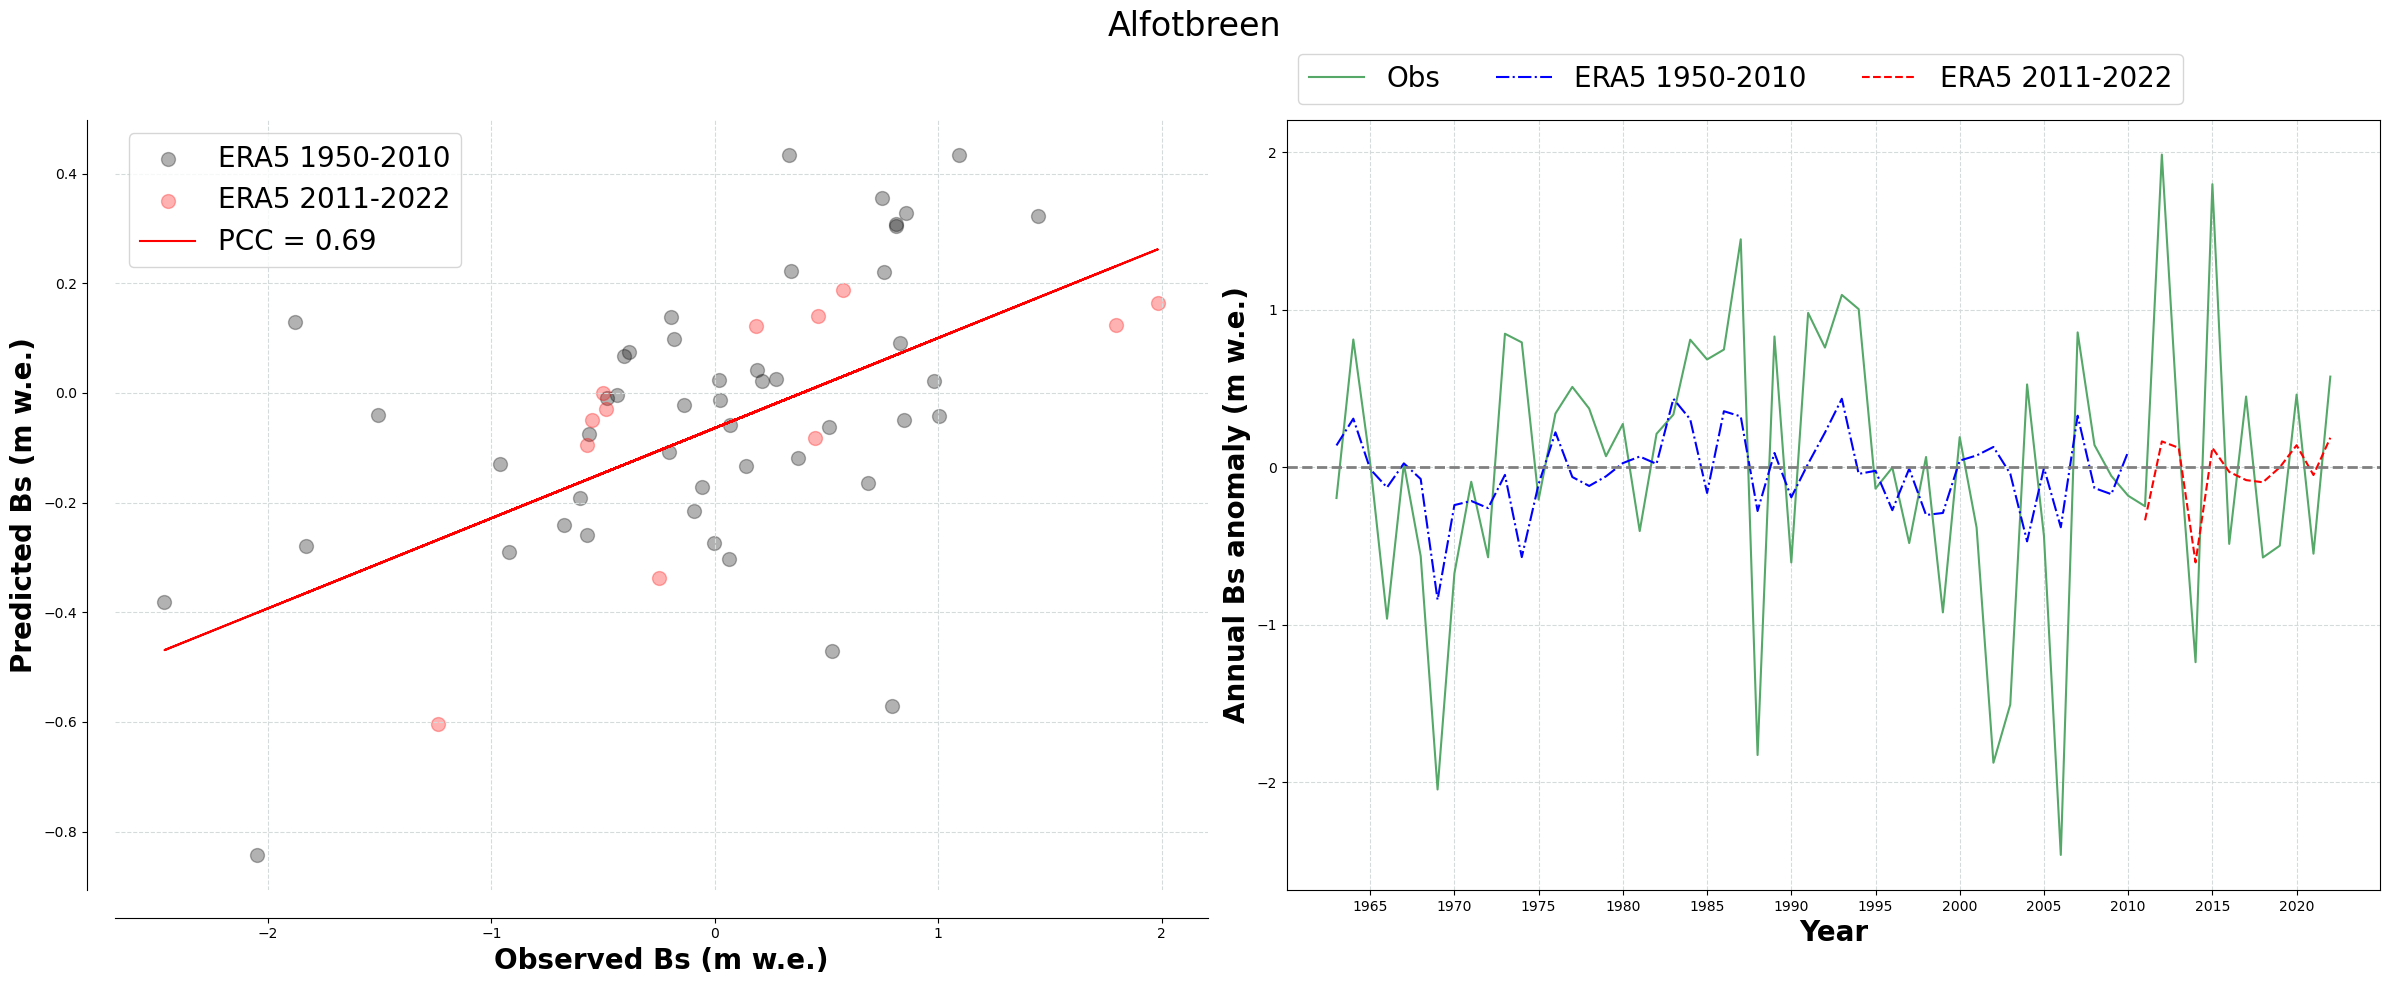

Processing station 2/11: Austdalsbreen
extracting information for the station:  Austdalsbreen
extracting information for the station:  Austdalsbreen


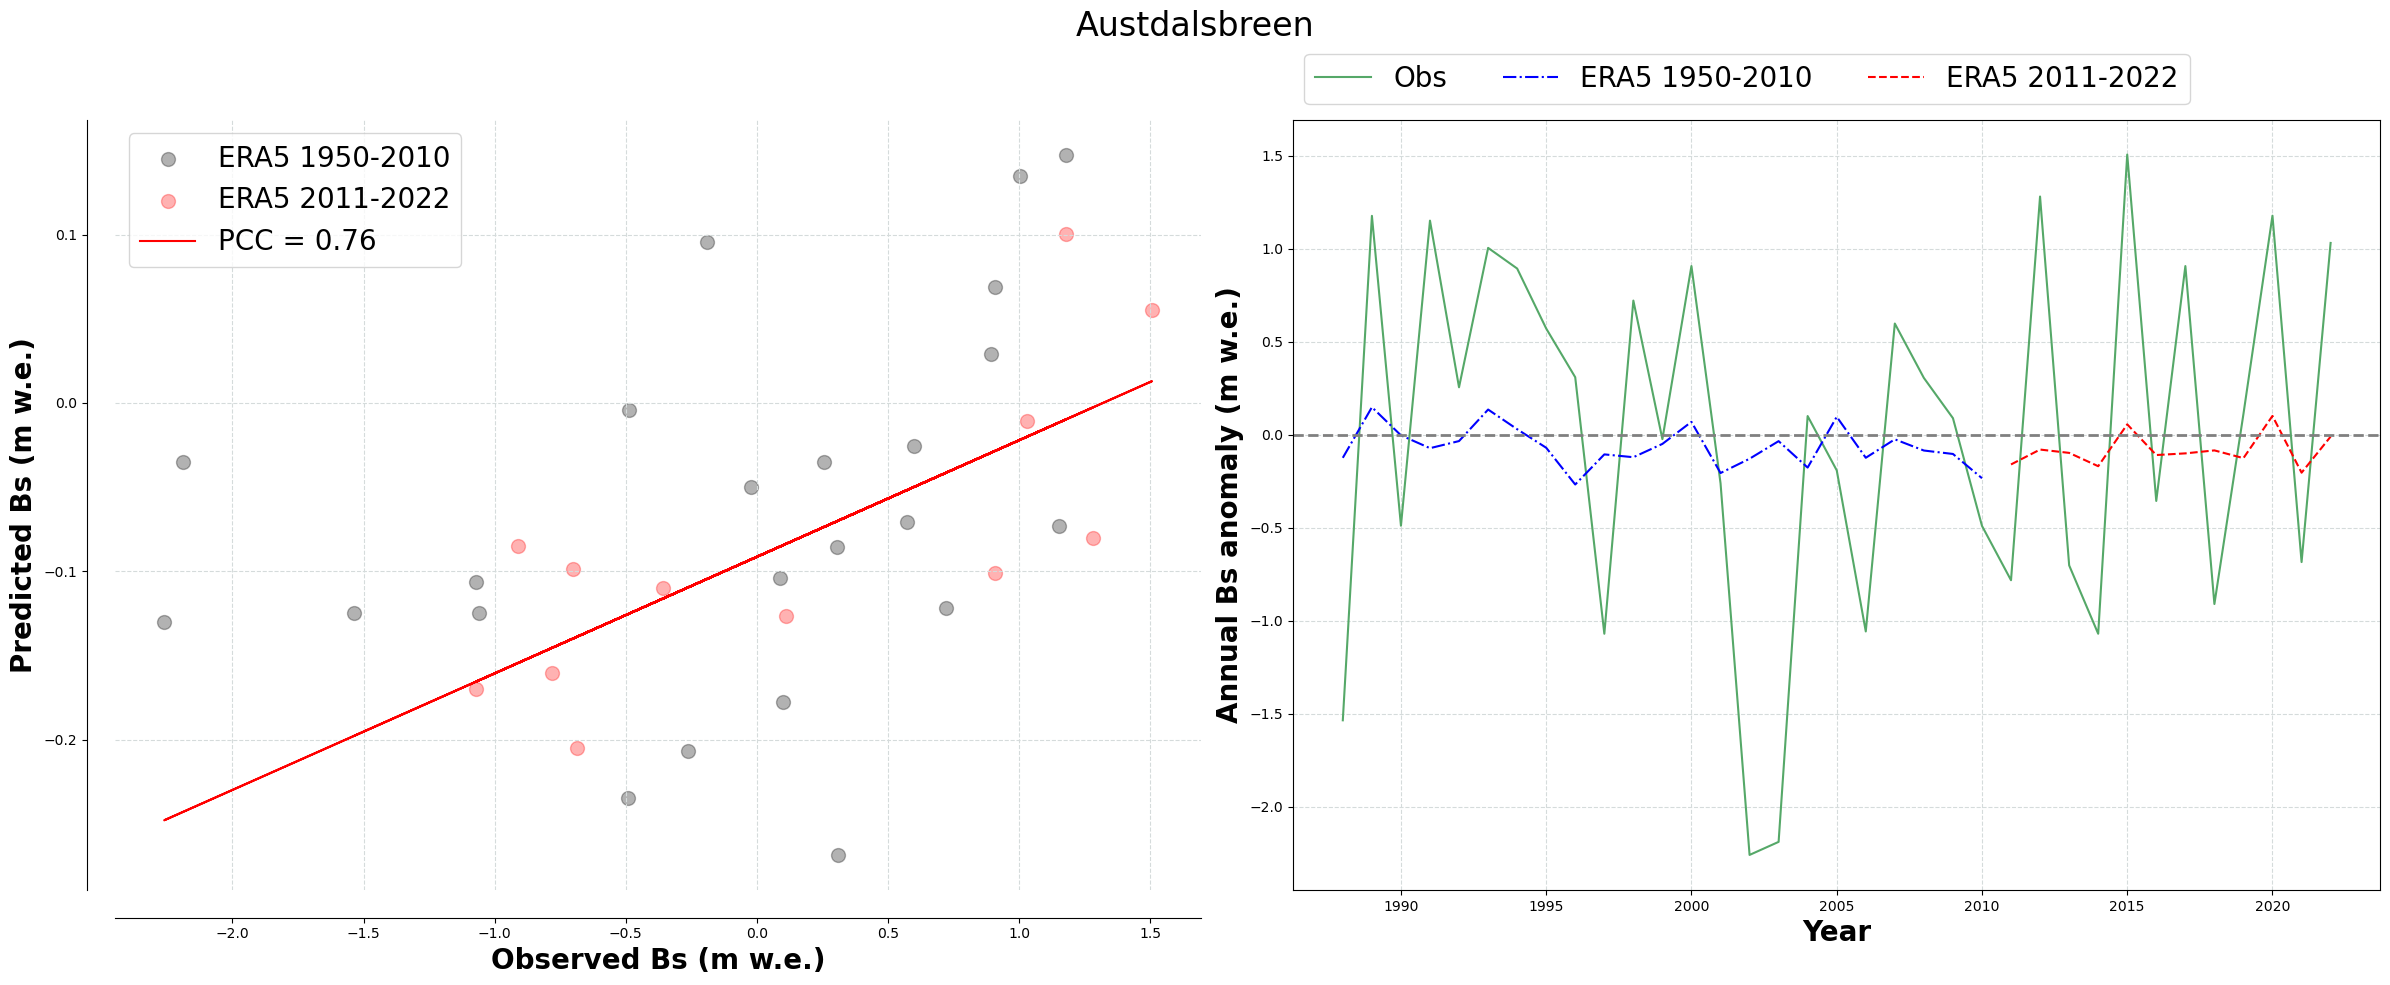

Processing station 3/11: Engabreen
extracting information for the station:  Engabreen
extracting information for the station:  Engabreen


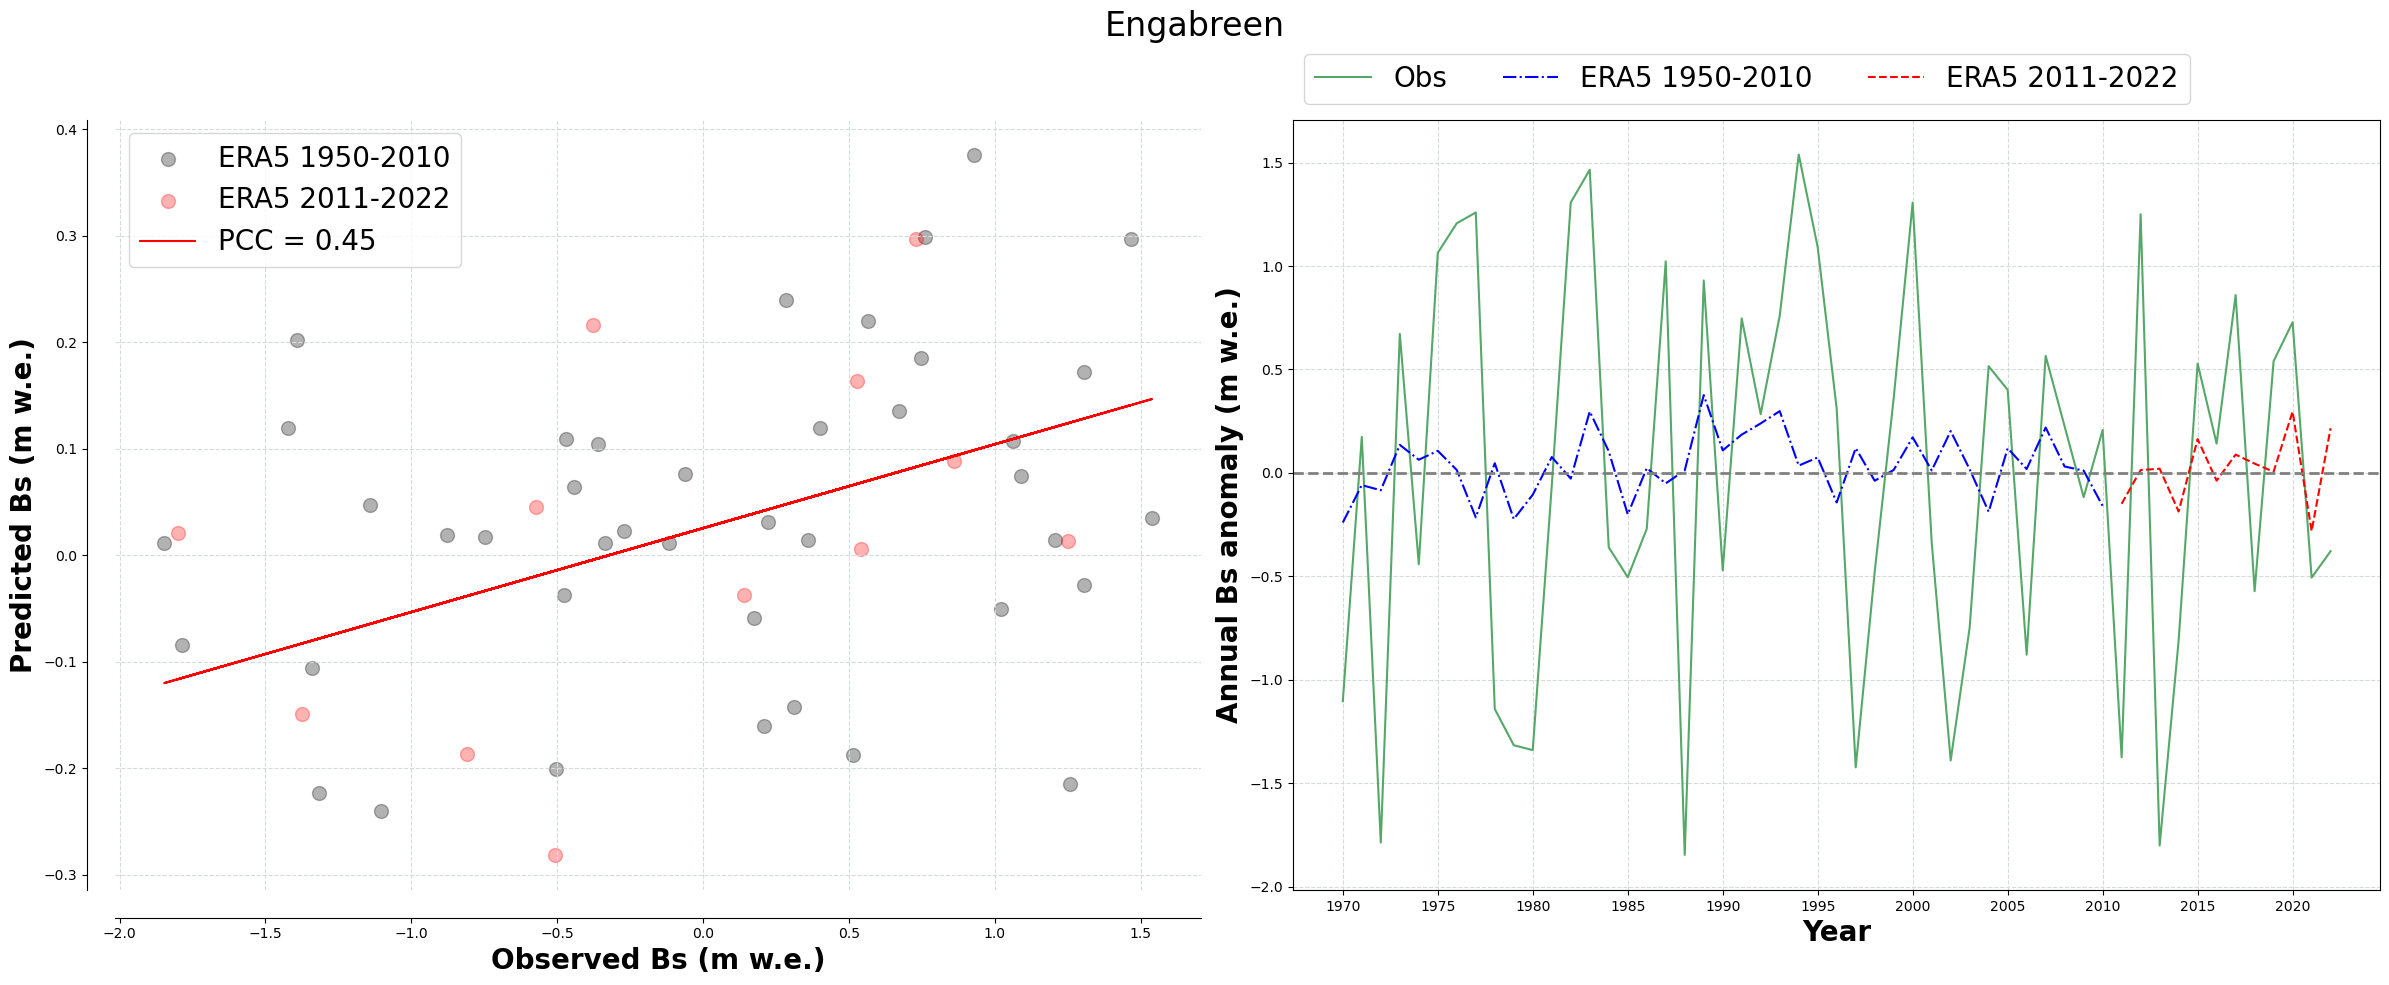

Processing station 4/11: Grafjellsbrea
extracting information for the station:  Grafjellsbrea
extracting information for the station:  Grafjellsbrea


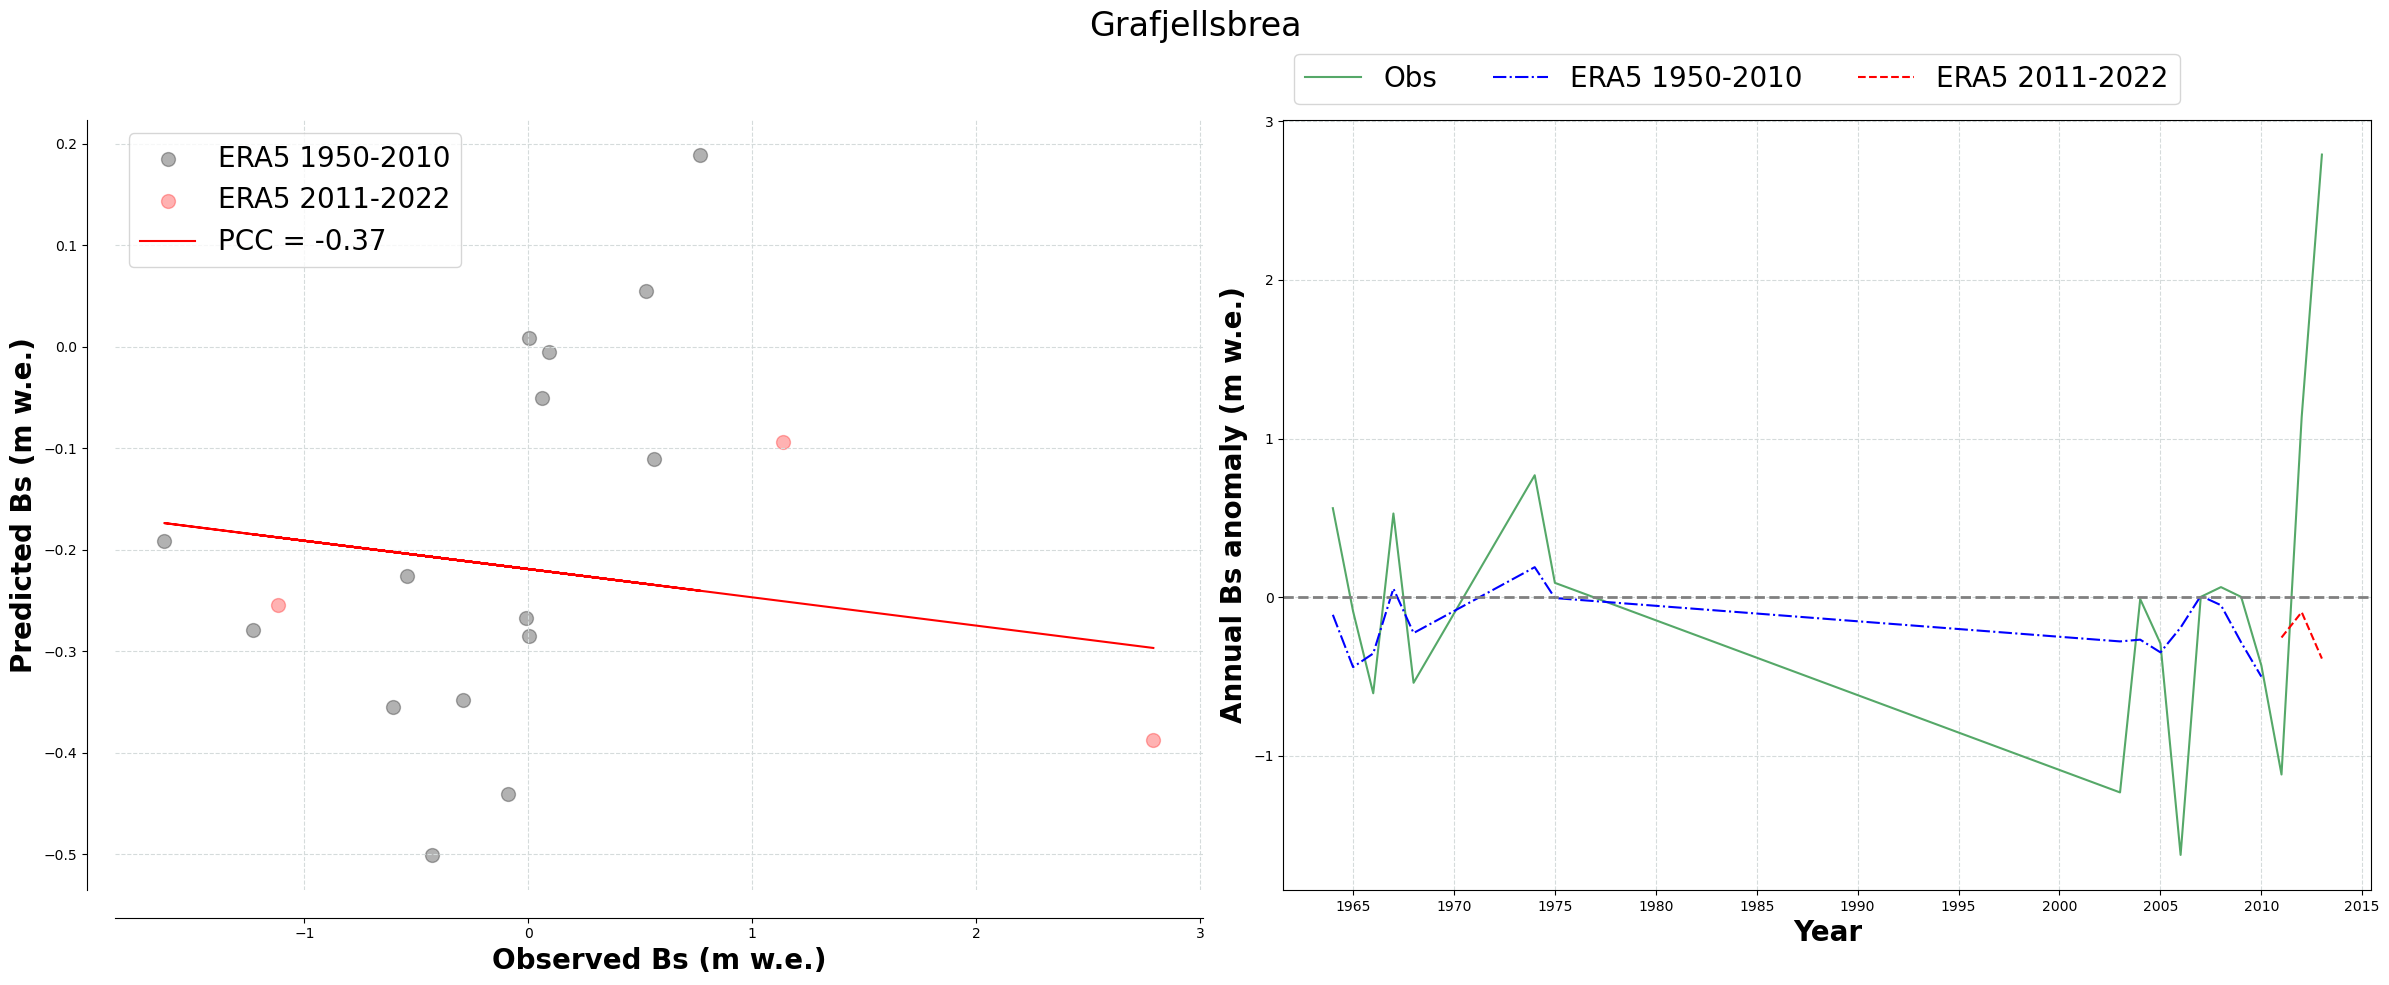

Processing station 5/11: Grasubreen
extracting information for the station:  Grasubreen
extracting information for the station:  Grasubreen


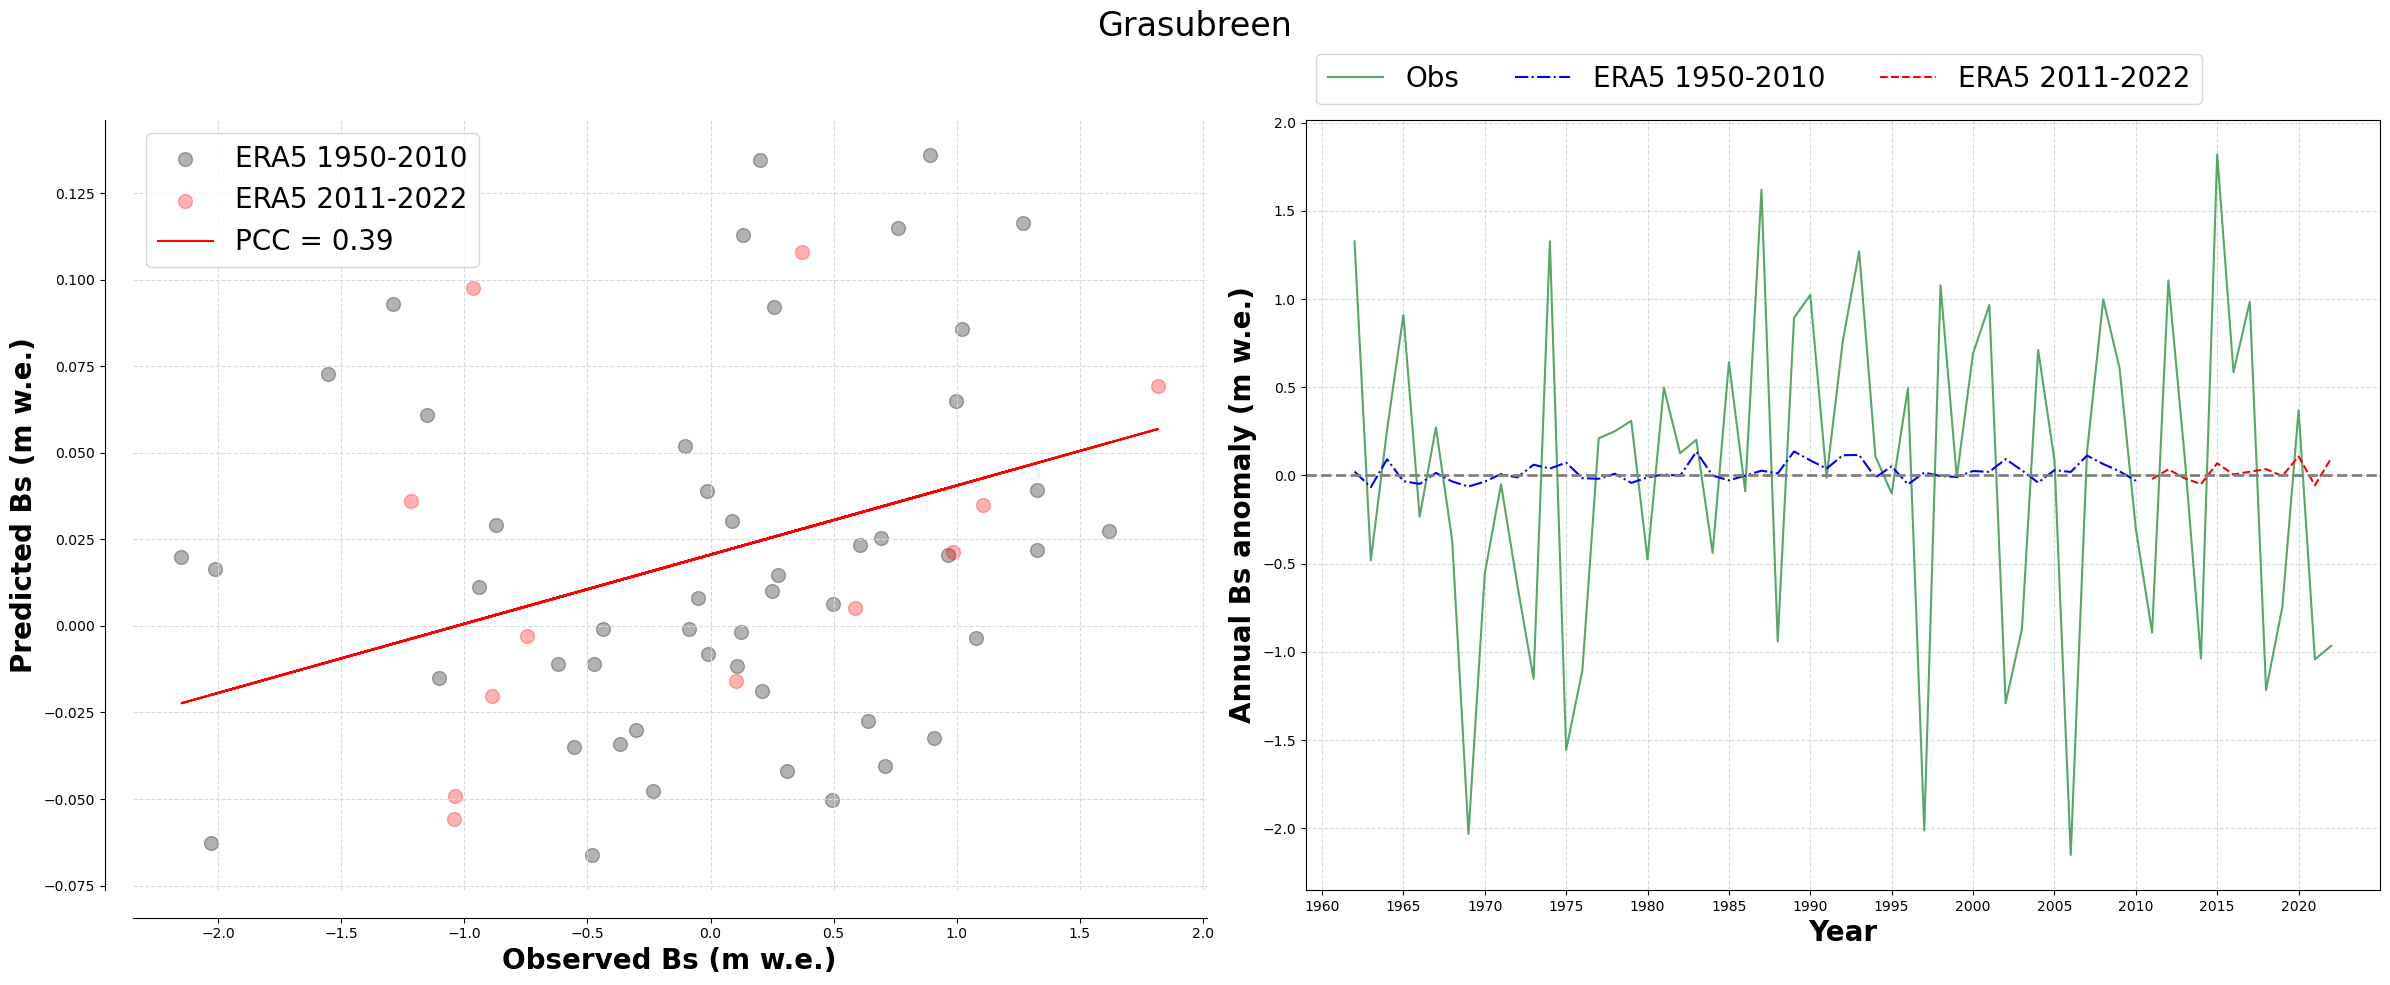

Processing station 6/11: Hansebreen
extracting information for the station:  Hansebreen
extracting information for the station:  Hansebreen


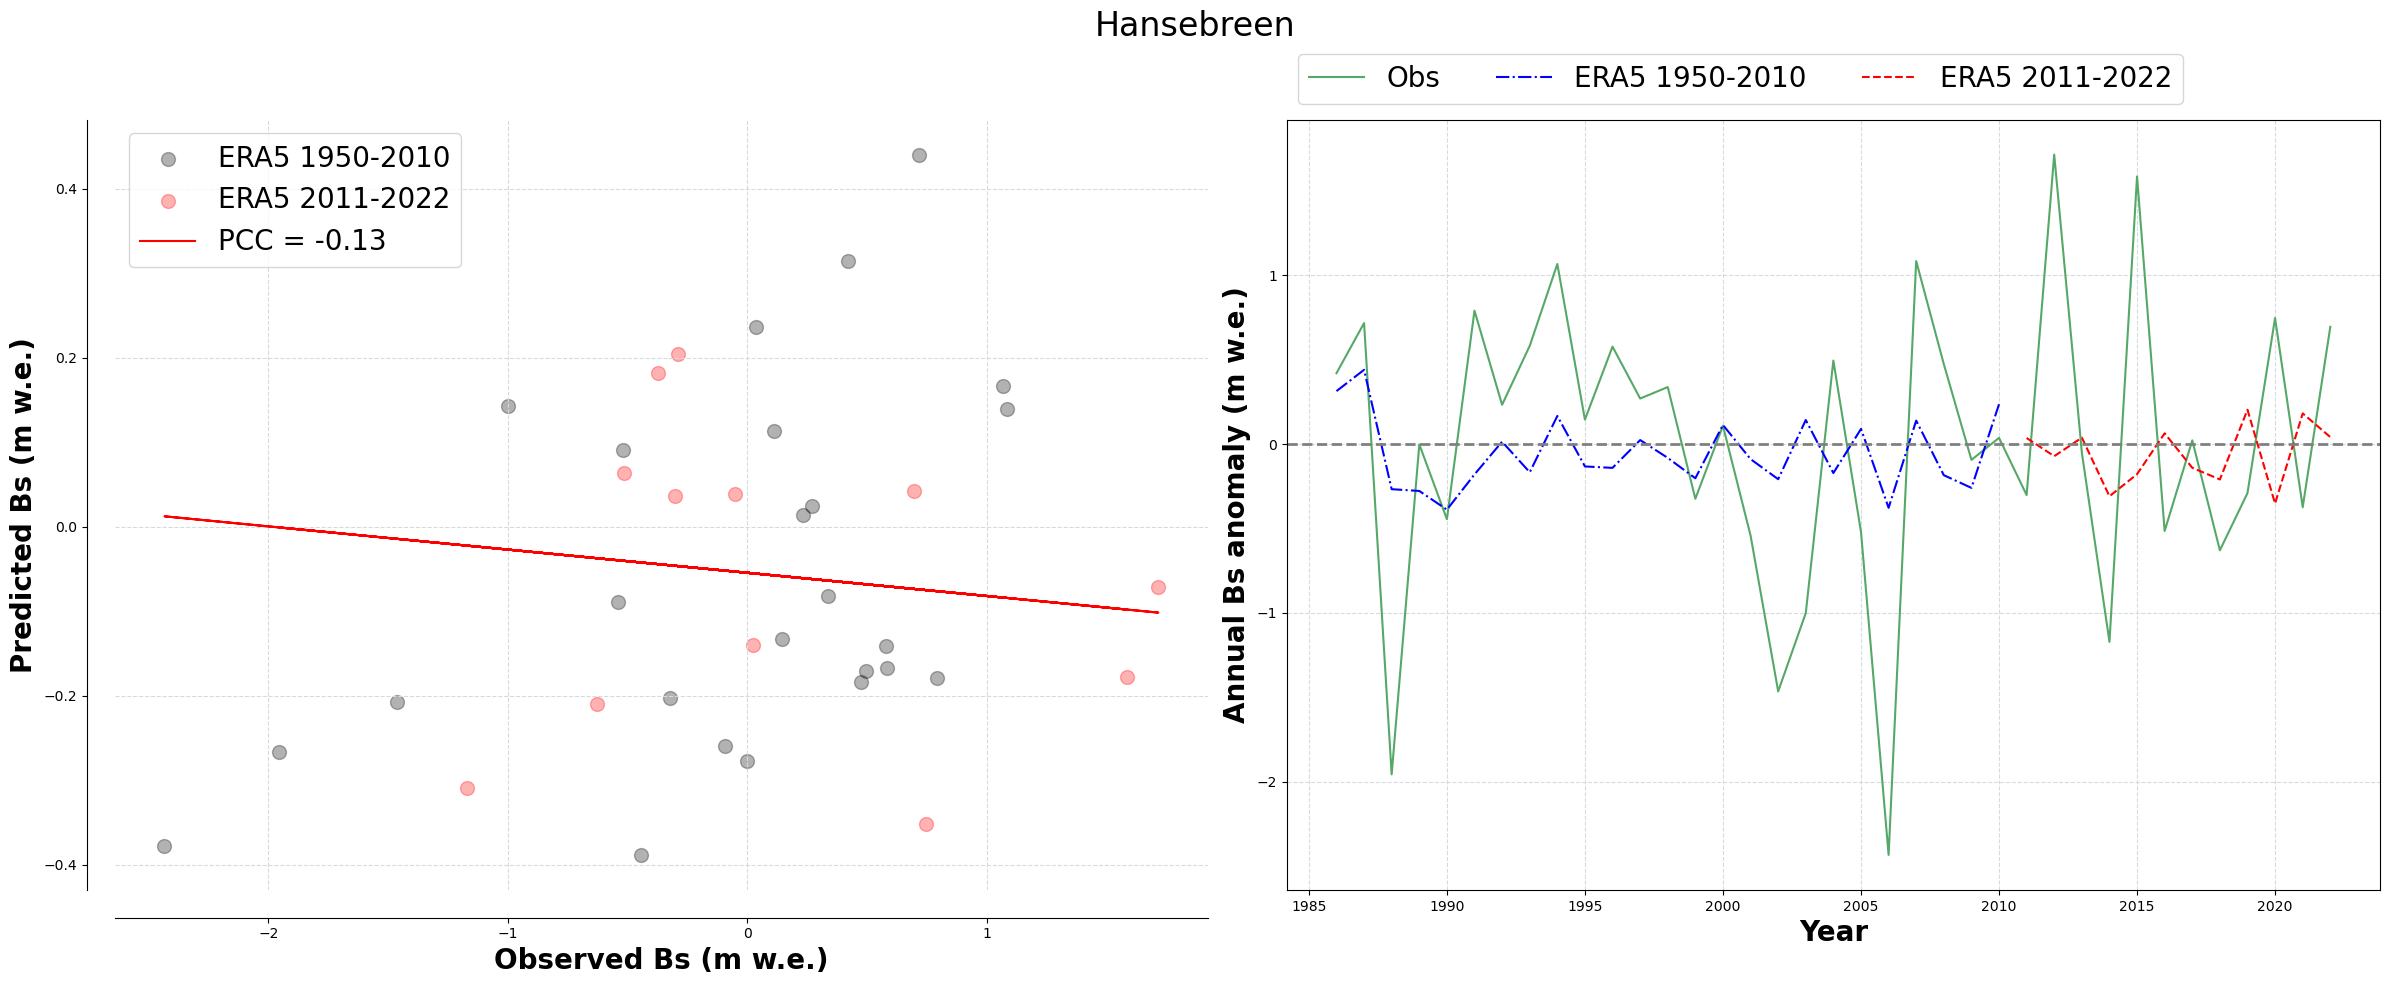

Processing station 7/11: Hellstugubreen
extracting information for the station:  Hellstugubreen
extracting information for the station:  Hellstugubreen


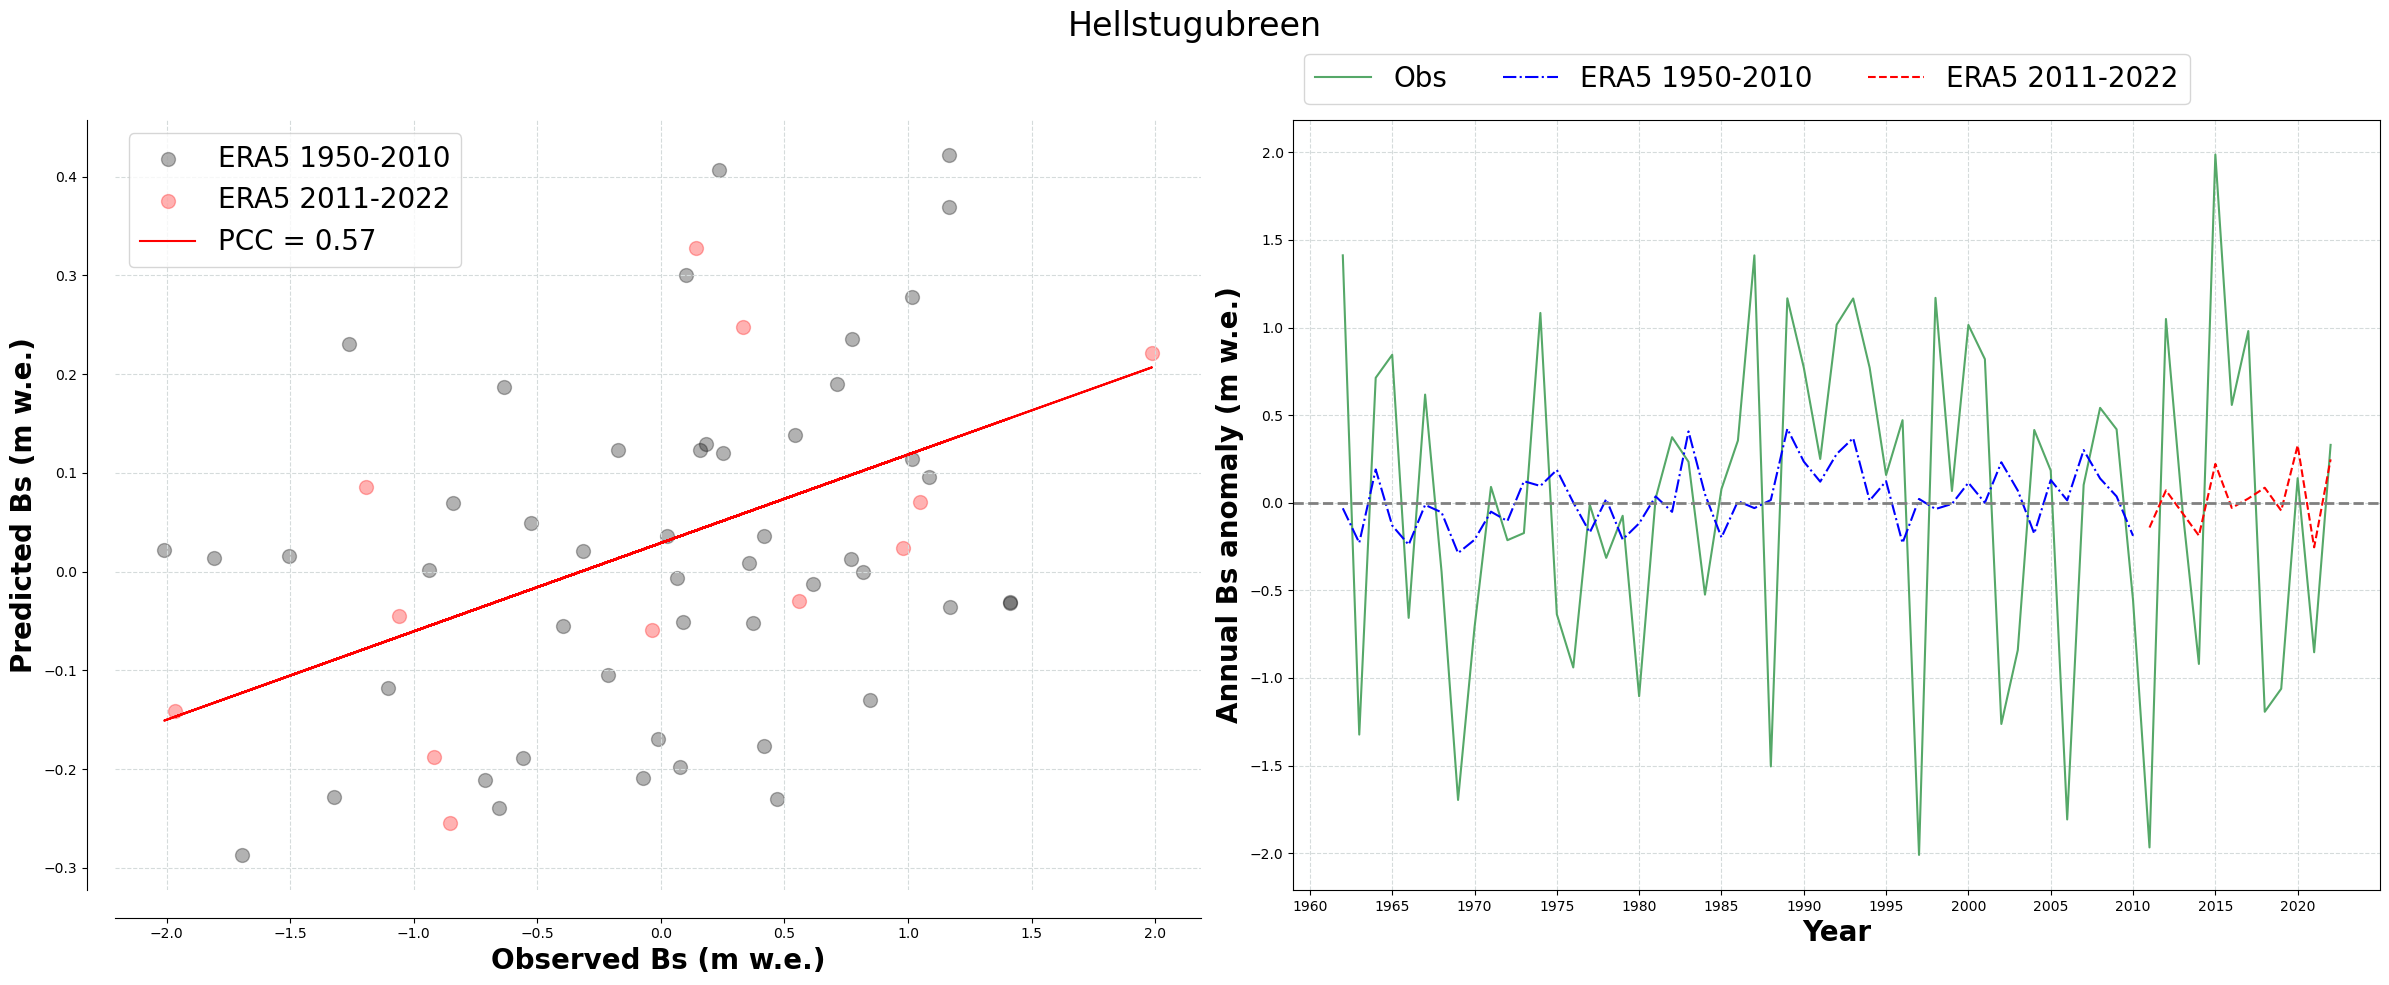

Processing station 8/11: Langfjordjokelen
extracting information for the station:  Langfjordjokelen
extracting information for the station:  Langfjordjokelen


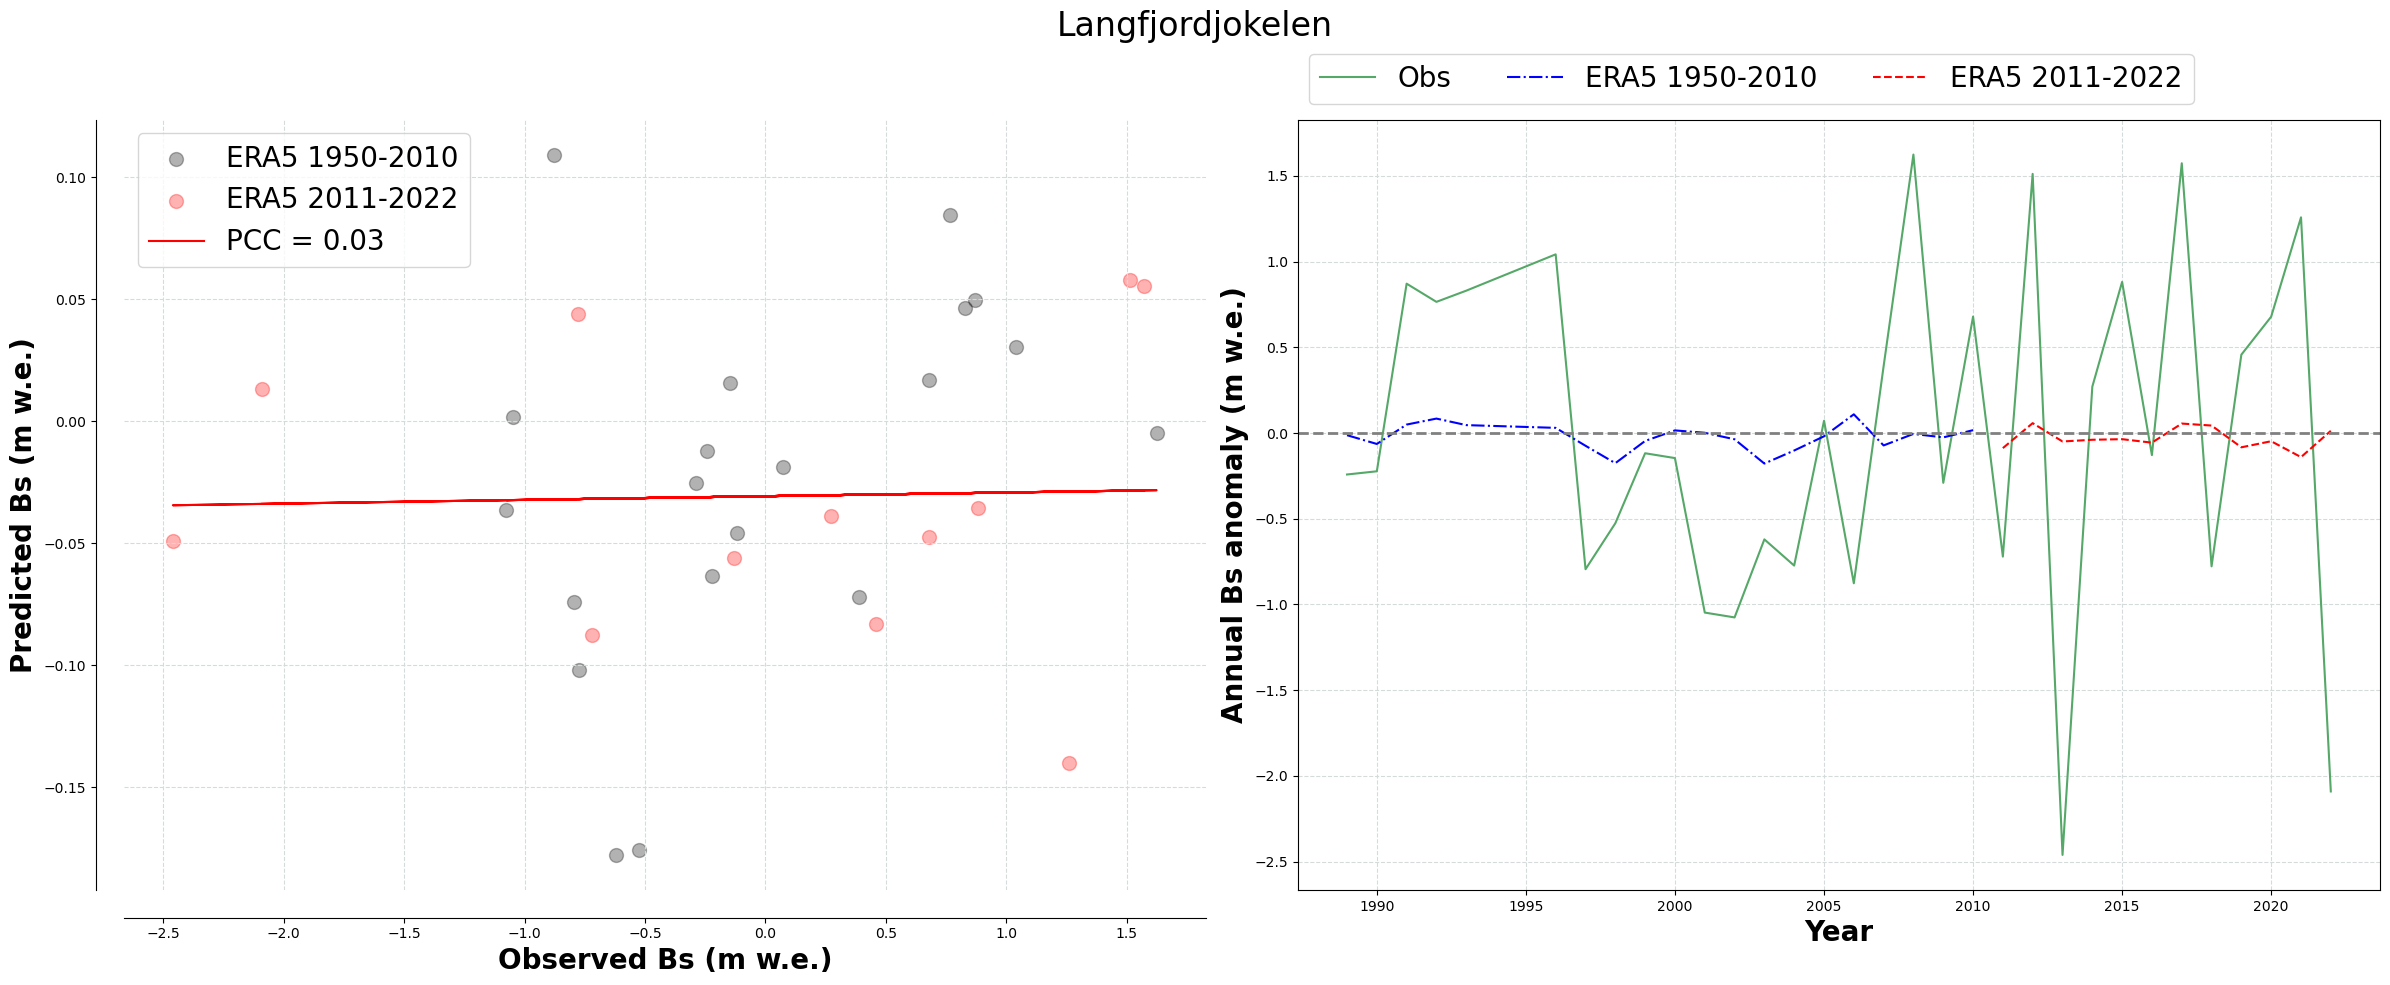

Processing station 9/11: Nigardsbreen
extracting information for the station:  Nigardsbreen
extracting information for the station:  Nigardsbreen


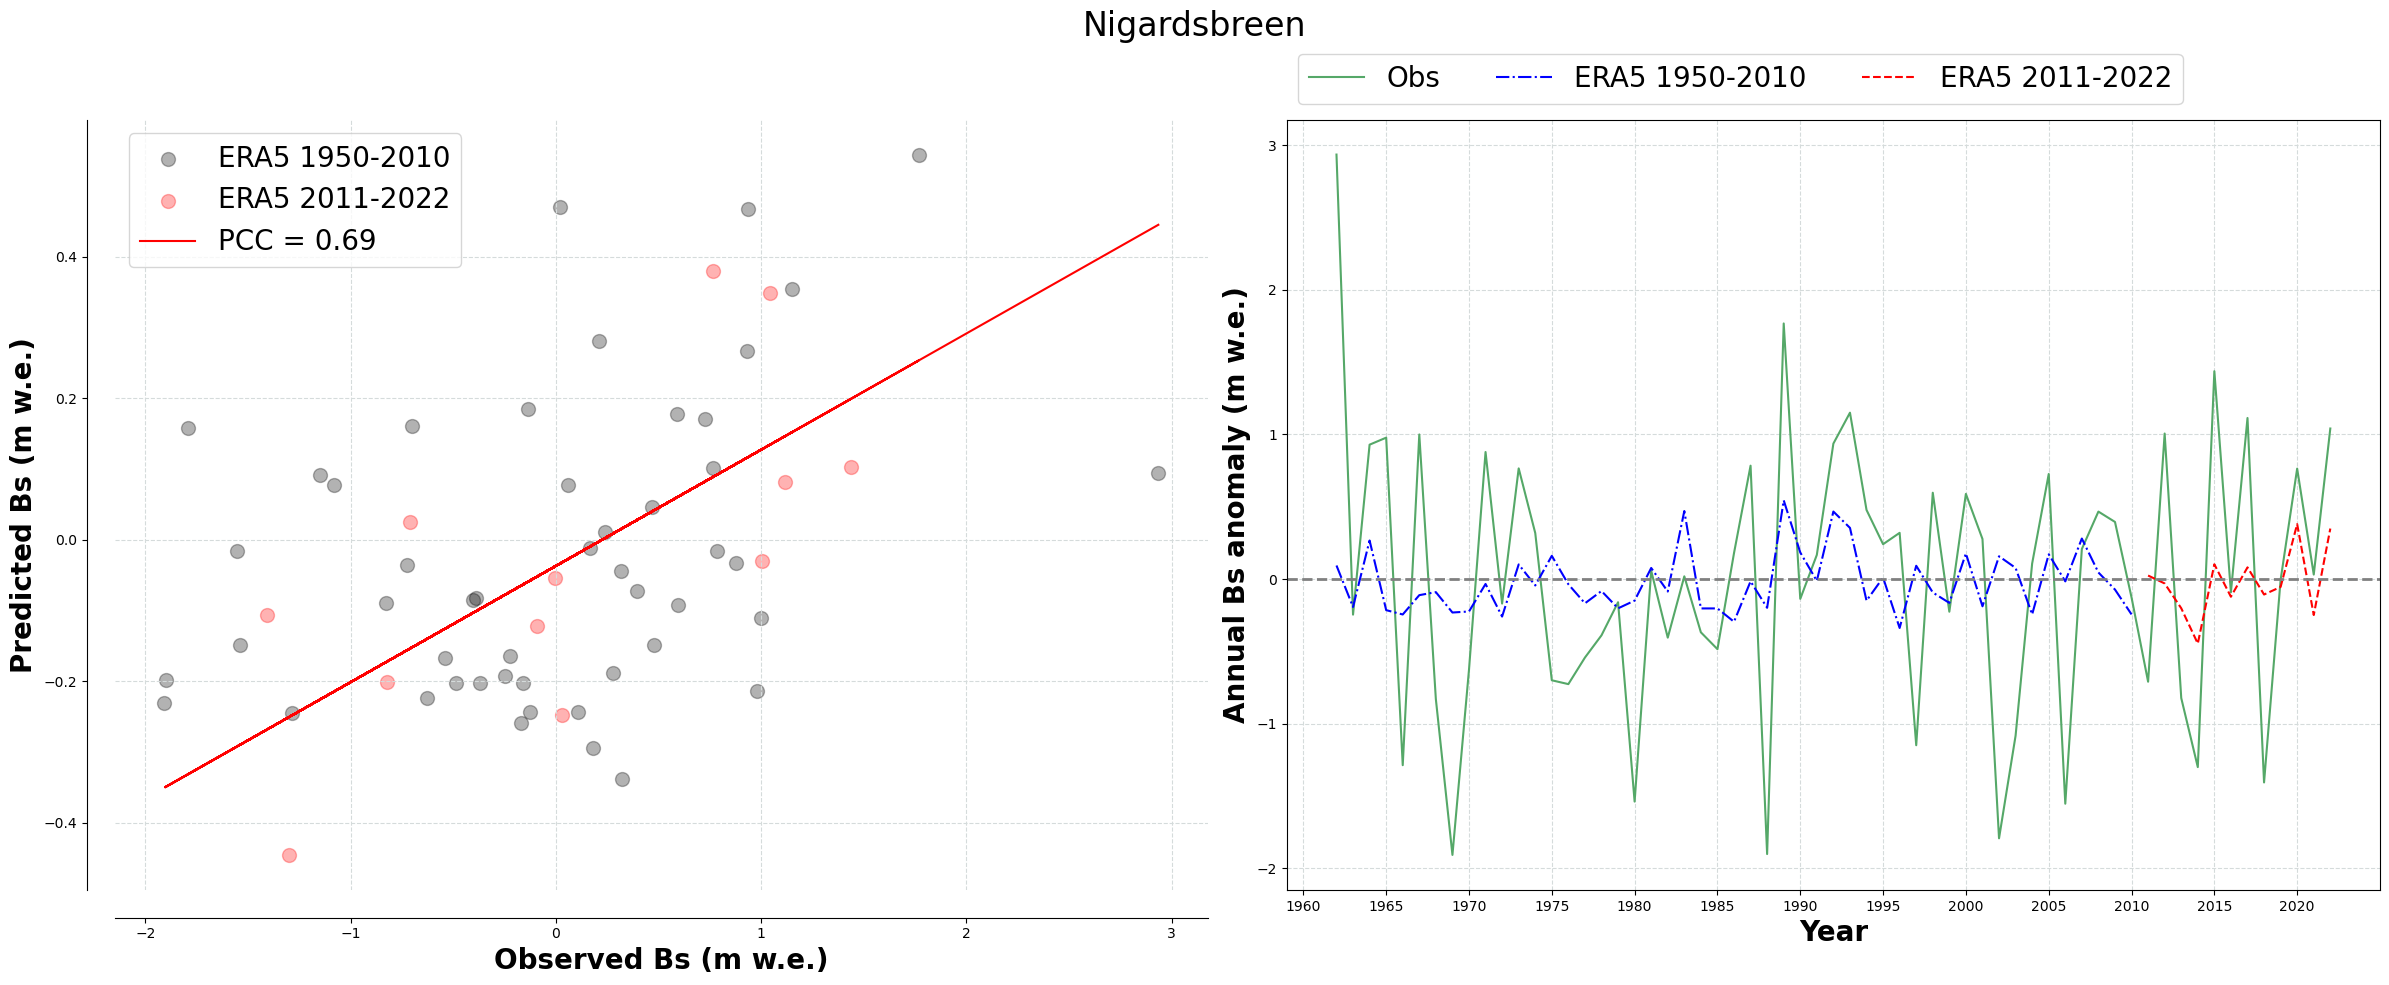

Processing station 10/11: Rembesdalskaka
extracting information for the station:  Rembesdalskaka
extracting information for the station:  Rembesdalskaka


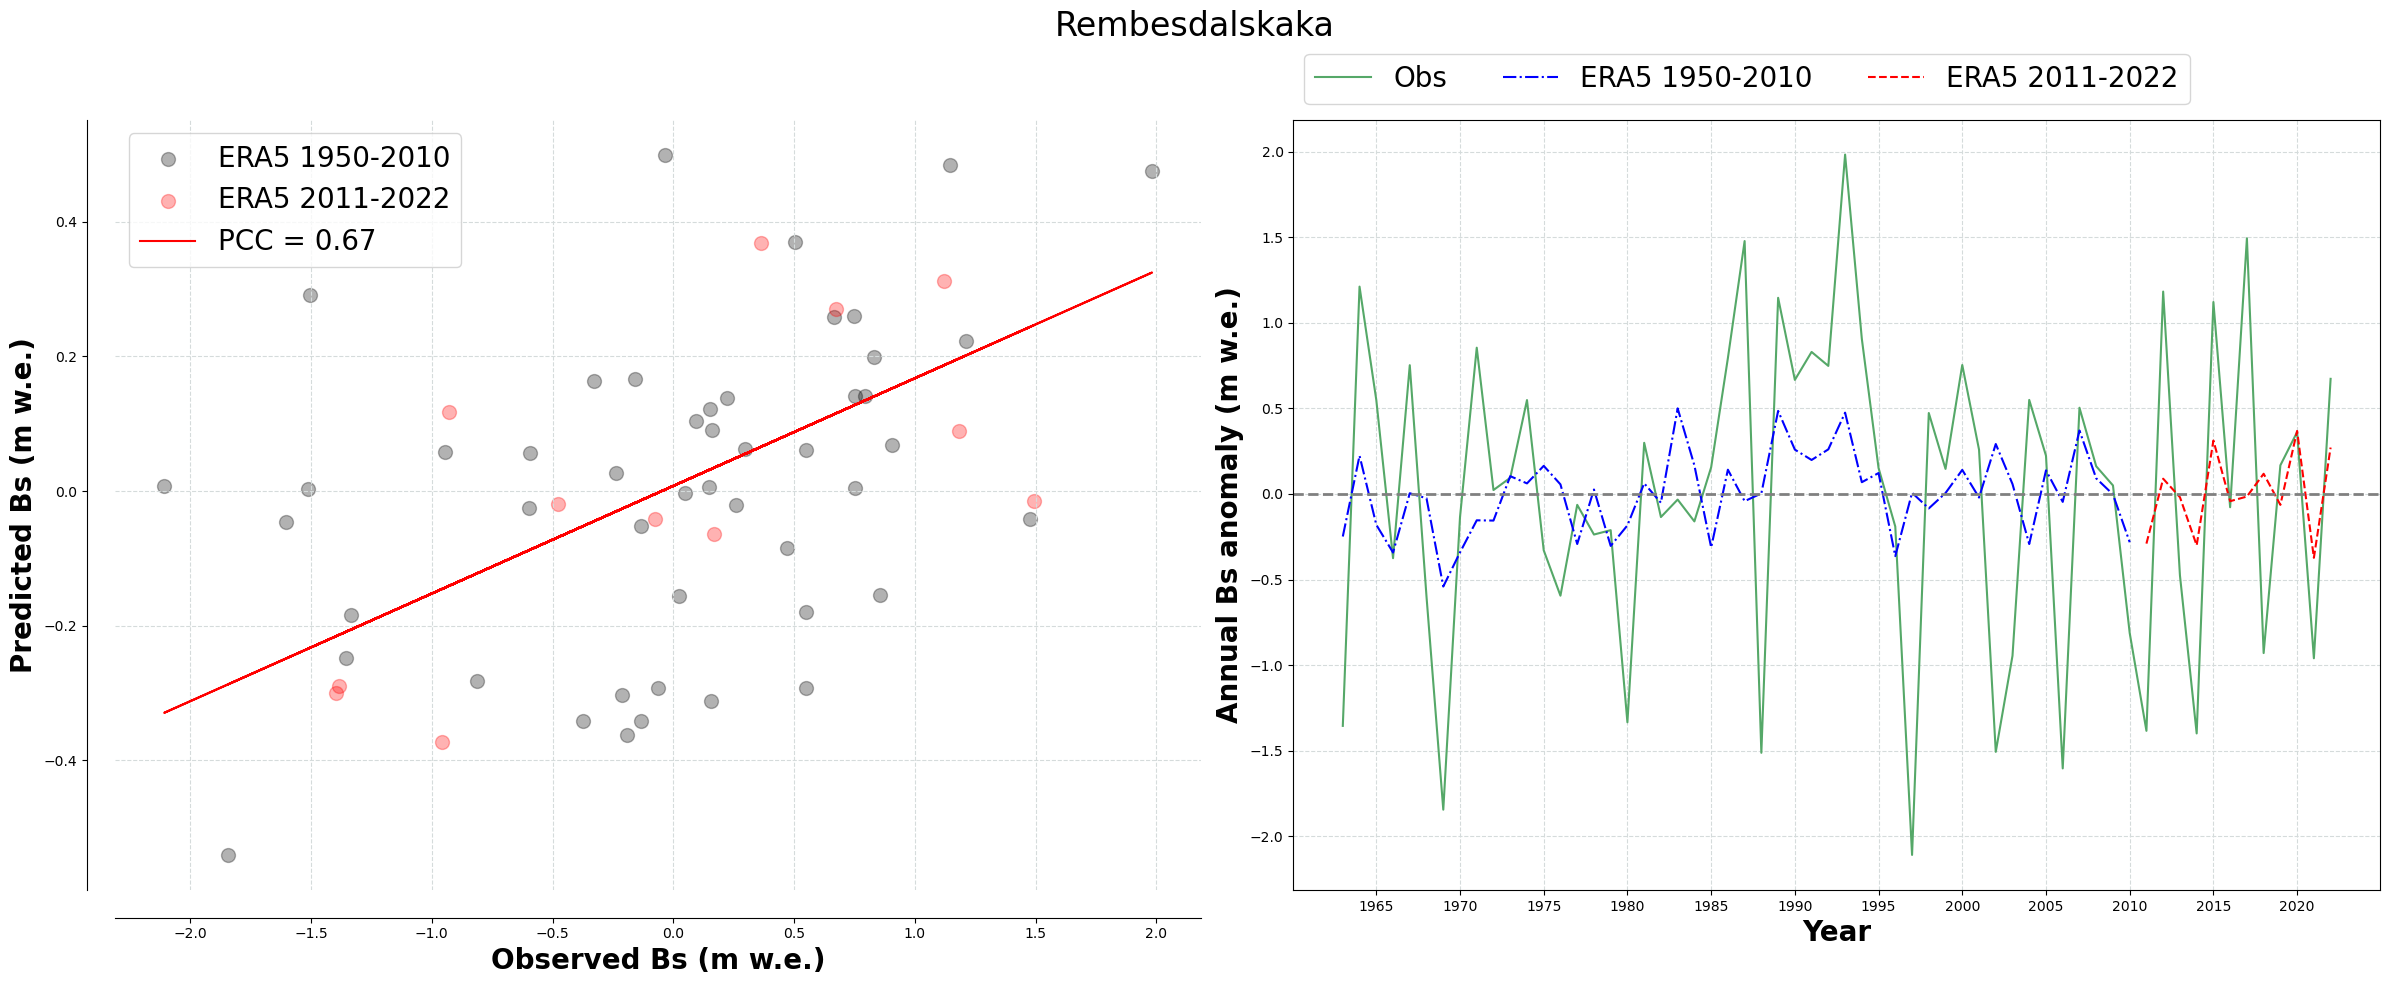

Processing station 11/11: Storbreen
extracting information for the station:  Storbreen
extracting information for the station:  Storbreen


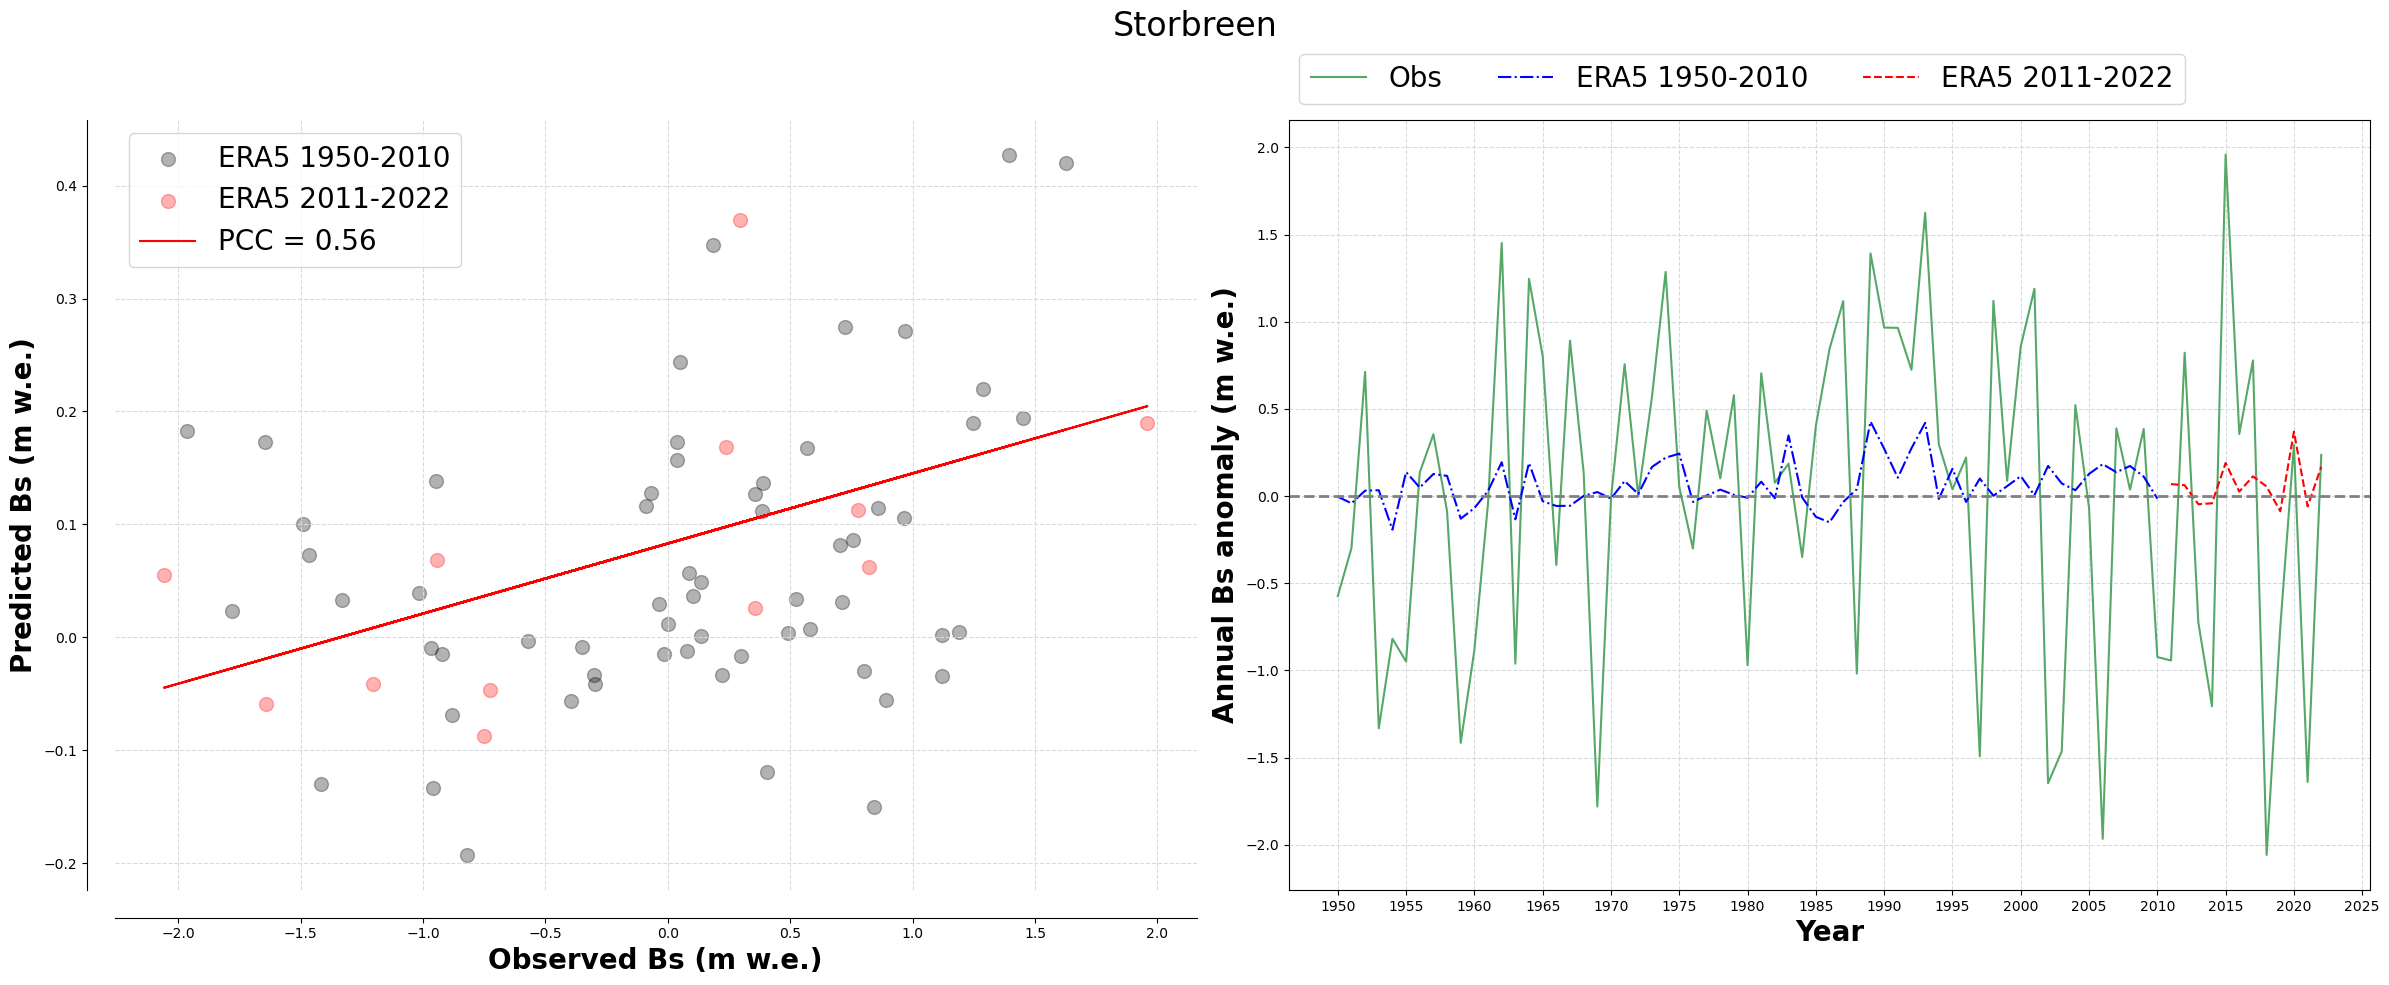

In [5]:
from pyESD.plot import lineplot, scatterplot
import matplotlib.pyplot as plt

# Input
stationnames = glaciernames
filename = "bs_" 
# path_to_data = r"C:\Users\danis\Desktop\Danish\Prediction Results\Bs"
path_to_data= os.path.expanduser("~/Desktop/Danish/CMIP Prediction Results/Bs/Voting")

for i, name in enumerate(stationnames):
    print(f"Processing station {i+1}/{len(stationnames)}: {stationnames[i]}")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

    scatterplot(
        station_num=i,
        stationnames=stationnames,
        path_to_data=path_to_data,
        filename=filename,
        ax=ax1,
        method='Voting',
        ylabel="Predicted Bs (m w.e.)",
        xlabel="Observed Bs (m w.e.)",

        obs_train_name="obs 1950-2010", 
        obs_test_name="obs 2011-2022", 
        val_predict_name="ERA5 1950-2010", 
        test_predict_name="ERA5 2011-2022",
    )

    lineplot(
        station_num=i,
        stationnames=stationnames,
        path_to_data=path_to_data,
        filename="bs_",
        method="Voting",
        ylabel="Annual Bs anomaly (m w.e.)",
        xlabel="Year",
        ax=ax2,

        obs_train_name="obs 1950-2010", 
        obs_test_name="obs 2011-2022", 
        val_predict_name="ERA5 1950-2010", 
        test_predict_name="ERA5 2011-2022",
    )
    fig.suptitle(f"{name}", fontsize=24, y=0.98)
    plt.tight_layout()
    plt.show()


